In [2]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from scipy import stats
from regression_modelling.constants import (
    DEMOGRAPHIC_PREDICTORS, 
    APPROVED_WITHIN_PREDICTORS,
    PROPERTY_PREDICTORS,
    PROPERTY_LAG_COLS,
    TRANSIT_PREDICTORS,
    ACS_TRANSIT_PREDICTORS,
    IMAGERY_PREDICTORS,
    ROADWAY_PREDICTORS,
    )
from crime_blockgroup_mapping.constants import CITIES
from regression_modelling.models.dataset import load_pooled_table, target_pool
from regression_modelling.distributions.screening import (
    within_city_spearman, within_city_corr_matrix, between_share, vif_table)

In [4]:
# Same rows the models fit on (pop > 0, daytime_pop >= 100), all 20 cities stacked.
pool = load_pooled_table(target_pool("wprop", verbose=False))
# wtotal_rate is filled in every city but is only valid where the feed carries violent crime.
WTOTAL_CITIES = target_pool("wtotal", verbose=False)
TARGETS = {"total":    ("wtotal_rate", WTOTAL_CITIES),
           "property": ("wprop_rate",  sorted(pool["city"].unique()))}

# Model tables are already imputed, so Q1 reads the RAW national matrix, aligned to pool rows.
raw = pd.read_parquet(_root / "data/interim/features/bg_predictors.parquet").set_index("geoid")
raw = raw.reindex(pool["geoid"])
raw.index = pool.index

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  sacramento          366 BGs
  san_francisco       679 BGs
  pittsburgh          317 BGs
  kansas_city         473 BGs
  columbus            637 BGs
  jacksonville        550 BGs
  detroit             622 BGs
  philadelphia       1338 BGs
  milwaukee           567 BGs
  baltimore           618 BGs
  dc                  571 BGs
  oakland             353 BGs
  new_york           6712 BGs
  dallas              869 BGs
  denver              572 BGs
  las_vegas           439 BGs
  seattle             537 BGs
  pooled            20439 BGs across 20 cities
  dropped 307 zero/NaN-pop BGs -> 20132 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 78 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 20054 remain


In [5]:
# Families list RAW columns (for skew / transform choice); model_cols() gives what models use.
FAMILIES = {
    "demographic": DEMOGRAPHIC_PREDICTORS + APPROVED_WITHIN_PREDICTORS,
    "property":    PROPERTY_PREDICTORS + PROPERTY_LAG_COLS,
    "transit":     TRANSIT_PREDICTORS + ACS_TRANSIT_PREDICTORS,
    "imagery":     IMAGERY_PREDICTORS,
    "roadway":     ROADWAY_PREDICTORS,
}
FAMILIES = {f: [c for c in cols if c in pool.columns] for f, cols in FAMILIES.items()}

def model_form(col):
    if col == "transit_service_intensity":
        return "transit_service_intensity_logc"
    return f"{col}_log" if f"{col}_log" in pool.columns else col

def model_cols(family):
    cols = [model_form(c) for c in FAMILIES[family]]
    if family == "transit":
        cols = ["transit_has_transit", *cols]
    return list(dict.fromkeys(cols))

def _skew(s):
    return s.dropna().astype(float).skew()

In [6]:
# ---------- Q1 + Q2: missingness and skew (static numbers) ----------
def skew_table(family):
    """One row per raw variable: missing share before imputation, zero share, range, skew of
    the raw / current model form / candidate transforms; `best` = smallest |skew|."""
    rows = []
    for c in FAMILIES[family]:
        x = pool[c].astype(float)
        r = {"variable": c,
             "pct_missing_raw": raw[c].isna().mean() * 100 if c in raw.columns else np.nan,
             "pct_zero": (x == 0).mean() * 100,
             "min": x.min(), "median": x.median(), "max": x.max(),
             "model_form": model_form(c),
             "skew_raw": _skew(x),
             "skew_model": _skew(pool[model_form(c)]),
             "skew_log1p": _skew(np.log1p(x)) if x.min() > -1 else np.nan,
             "skew_sqrt": _skew(np.sqrt(x)) if x.min() >= 0 else np.nan,
             "skew_yeojohnson": pd.Series(stats.yeojohnson(x.dropna())[0]).skew()}
        cands = {k: r[f"skew_{k}"] for k in ("raw", "log1p", "sqrt", "yeojohnson")}
        r["best"] = min((k for k, v in cands.items() if pd.notna(v)), key=lambda k: abs(cands[k]))
        r["flag"] = ("zero-inflated: consider has_X flag + log1p" if r["pct_zero"] > 30
                     else "high raw missing" if r["pct_missing_raw"] > 10 else "")
        rows.append(r)
    return pd.DataFrame(rows).set_index("variable").round(2)

# ---------- Q2: distribution of ONE variable, all 20 cities together ----------
def plot_dist(var, transform=None, clip_q=None, by_city=True, bins=60, df=None):
    """Left: pooled histogram, skew in the title. Right: per-city boxplot (is the shape shared
    or driven by a few cities?). transform: None | 'log1p' | 'sqrt' | 'yeojohnson'.
    clip_q (e.g. 0.99) trims the long tail from the histogram view only."""
    df = pool if df is None else df
    x = df[var].astype(float)
    if transform == "log1p":
        x = np.log1p(x)
    elif transform == "sqrt":
        x = np.sqrt(x)
    elif transform == "yeojohnson":
        nn = x.dropna()
        x = pd.Series(stats.yeojohnson(nn)[0], index=nn.index).reindex(x.index)
    label = f"{transform}({var})" if transform else var

    fig, axes = plt.subplots(1, 2 if by_city else 1, figsize=(15 if by_city else 7, 4.5),
                             gridspec_kw={"width_ratios": [1, 1.5]} if by_city else None)
    axes = np.atleast_1d(axes)
    h = x.dropna()
    if clip_q:
        h = h[h <= h.quantile(clip_q)]
    axes[0].hist(h, bins=bins, color="steelblue", edgecolor="white")
    axes[0].axvline(x.median(), color="k", ls="--", lw=1)
    axes[0].set_title(f"{label}\nskew={_skew(x):.2f}   zero={(x == 0).mean():.0%}   "
                      f"n={x.notna().sum():,}", fontsize=10)
    axes[0].set_ylabel("BGs")
    if by_city:
        d = pd.DataFrame({"city": df["city"], "x": x}).dropna()
        order = d.groupby("city")["x"].median().sort_values().index
        sns.boxplot(data=d, x="x", y="city", order=order, ax=axes[1],
                    fliersize=1, color="lightsteelblue")
        axes[1].set_title(f"{label} by city (sorted by median)", fontsize=10)
        axes[1].set_xlabel(label); axes[1].set_ylabel("")
    plt.tight_layout(); plt.show()

# ---------- Q3: predictor–predictor correlation ----------
def corr_heatmaps(cols, title, annot=True):
    """Pooled vs mean within-city Spearman. A pair correlated only in the pooled panel shares
    a city LEVEL, not a within-city pattern (that is the redundancy that matters for ranking)."""
    mats = {"pooled": pool[cols].corr(method="spearman"),
            "mean within-city": within_city_corr_matrix(pool, cols)}
    n = len(cols)
    fig, axes = plt.subplots(1, 2, figsize=(2 * max(6, 0.9 * n), max(5, 0.8 * n)))
    for ax, (name, m) in zip(axes, mats.items()):
        sns.heatmap(m, annot=annot, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                    square=True, cbar=False, ax=ax, annot_kws={"size": 7})
        ax.set_title(f"{title} — {name}")
    plt.tight_layout(); plt.show()

def top_pairs(cols, thresh=0.6):
    """Pairs with |mean within-city rho| >= thresh, with the pooled rho alongside."""
    w = within_city_corr_matrix(pool, cols)
    p = pool[cols].corr(method="spearman")
    rows = [{"a": a, "b": b, "within_rho": w.loc[a, b], "pooled_rho": p.loc[a, b]}
            for i, a in enumerate(cols) for b in cols[i + 1:] if abs(w.loc[a, b]) >= thresh]
    out = pd.DataFrame(rows, columns=["a", "b", "within_rho", "pooled_rho"])
    return out.sort_values("within_rho", key=abs, ascending=False).round(2)

# ---------- Q4: correlation with total / property crime, pooled vs within vs across cities ----------
def target_corr_table(cols):
    """Per target: pooled rho; median within-city rho; share of cities agreeing in sign;
    between-city rho of city medians (n = #cities, so noisy); and between-city variance share."""
    parts = {}
    for name, (t, cities) in TARGETS.items():
        d = pool[pool["city"].isin(cities)]
        W = within_city_spearman(d, cols, t)
        med = W.median(axis=1)
        city_med = d.groupby("city")[[*cols, t]].median()
        parts[name] = pd.DataFrame({
            "pooled":     d[cols].corrwith(d[t], method="spearman"),
            "within_med": med,
            "sign_agree": W.apply(lambda r: (np.sign(r.dropna()) == np.sign(r.median())).mean(),
                                  axis=1),
            "between":    city_med[cols].corrwith(city_med[t], method="spearman"),
            "n_cities":   W.notna().sum(axis=1)})
    tbl = pd.concat(parts, axis=1)
    tbl[("all", "between_share")] = between_share(pool, cols)
    return tbl.sort_values(("property", "within_med"), key=abs, ascending=False).round(2)

def city_corr_heatmap(cols, target="property"):
    """Within-city Spearman with the target, one column per city: which relationships hold
    everywhere and which flip sign by city."""
    t, cities = TARGETS[target]
    W = within_city_spearman(pool[pool["city"].isin(cities)], cols, t)
    W = W.loc[W.median(axis=1).abs().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(max(8, 0.6 * W.shape[1]), max(3, 0.45 * len(cols))))
    sns.heatmap(W, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                cbar=False, annot_kws={"size": 7}, ax=ax)
    ax.set_title(f"within-city Spearman with {t}"); plt.tight_layout(); plt.show()

print(f"pool: {len(pool):,} BGs across {pool['city'].nunique()} cities "
      f"(total-crime target valid in {len(WTOTAL_CITIES)})")
for f, cols in FAMILIES.items():
    print(f"  {f:12} raw={len(cols):>2}  model={len(model_cols(f)):>2}")

pool: 20,054 BGs across 20 cities (total-crime target valid in 10)
  demographic  raw= 8  model= 8
  property     raw=11  model=11
  transit      raw=11  model=12
  imagery      raw= 4  model= 4
  roadway      raw= 5  model= 5


**Questions / Hypotheses to Test:**
1. What % of block groups cover what % of crime?
    * gini index is in the range [0.4-0.6]; roughly 40-60% crime covered by 20% BGs in almost every city. 
    * Isolating these 20% is the first important job of our model
    * 50% of block groups hold only about 20% of crime. Ranking errors there cost little, so the modelling effort should focus on separating the top 20% from the next 30%
    * 80% crime covered by ~50% BGs
    * Detroit is hard to model because crime is spread across and not concentrated

2. Isolating those block groups:
    * Are there variables with too many null values?
    * ~~In each predictor family, what does the skew of each variable look like? What kind of transformations can be applied to take care of skew?~~ 
        - Skew doesn't matter for a tree-based model; we should focus on predictors instead 
    * Which variables are correlated with each other?
    * Which variables have the highest correlation with total crime and property crime? What about correlations across cities?

In [7]:
# --- crime concentration: what % of BGs hold what % of crime ---
CRIME_COUNTS = {"property": ("property_count", sorted(pool["city"].unique())),
                "total":    ("cl_total_count", WTOTAL_CITIES)}   # total valid in 10 cities only

def _concentration_curve(d, count_col, x_unit):
    """Cumulative (x, y): BGs sorted by crime (x_unit='bg') or crime per resident
    (x_unit='population'), descending. x = share of BGs / residents, y = share of crime."""
    c = d[count_col].astype(float).fillna(0).to_numpy()
    w = np.ones(len(d)) if x_unit == "bg" else d["population"].astype(float).to_numpy()
    key = c if x_unit == "bg" else c / np.where(w > 0, w, np.nan)
    order = np.argsort(-np.nan_to_num(key, nan=-np.inf))
    x = np.r_[0, np.cumsum(w[order]) / w.sum()]
    y = np.r_[0, np.cumsum(c[order]) / c.sum()]
    return x, y

def crime_concentration(scope="overall", crime="property", x_unit="bg",
                        bg_shares=(0.01, 0.05, 0.10, 0.20, 0.50),
                        crime_shares=(0.25, 0.50, 0.80), plot=True):
    """Concentration of actual crime for one scope.
    scope : 'overall' (all eligible cities pooled) or a city name, e.g. 'chicago'.
    crime : 'property' (property_count, 20 cities) or 'total' (cl_total_count, 10 cities).
    x_unit: 'bg' (share of block groups) or 'population' (share of residents).
    Returns a Series: crime share held by the top X% and the % needed to reach Y% of crime."""
    count_col, cities = CRIME_COUNTS[crime]
    if scope == "overall":
        d = pool[pool["city"].isin(cities)]
    elif scope in cities:
        d = pool[pool["city"] == scope]
    else:
        raise ValueError(f"scope must be 'overall' or one of {cities}")
    x, y = _concentration_curve(d, count_col, x_unit)
    unit = "bg" if x_unit == "bg" else "pop"

    row = {"n_bg": len(d), "crimes": int(d[count_col].sum()),
           "zero_crime_bg_pct": round((d[count_col].fillna(0) == 0).mean() * 100, 1),
           "gini": round(2 * np.trapezoid(y, x) - 1, 3)}
    for s in bg_shares:
        row[f"crime_in_top{s:.0%}_{unit}"] = round(float(np.interp(s, x, y)) * 100, 1)
    for s in crime_shares:
        row[f"{unit}_pct_for_{s:.0%}_crime"] = round(float(np.interp(s, y, x)) * 100, 1)

    if plot:
        fig, ax = plt.subplots(figsize=(5.5, 5))
        ax.plot(x * 100, y * 100, lw=2, label=scope)
        ax.plot([0, 100], [0, 100], "k--", lw=1, label="equal spread")
        for s in bg_shares:
            v = np.interp(s, x, y) * 100
            ax.scatter(s * 100, v, s=20, zorder=3)
            ax.annotate(f"{s:.0%} → {v:.0f}%", (s * 100, v), xytext=(6, -10),
                        textcoords="offset points", fontsize=8)
        ax.set_xlabel(f"% of {'block groups' if x_unit == 'bg' else 'residents'} (most crime first)")
        ax.set_ylabel(f"% of {crime} crime")
        ax.set_title(f"{crime} crime concentration — {scope}  (gini={row['gini']:.2f})")
        ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
    return pd.Series(row, name=scope)

def concentration_table(crime="property", x_unit="bg"):
    """crime_concentration for 'overall' + every eligible city, sorted by top-10% share."""
    cities = CRIME_COUNTS[crime][1]
    tbl = pd.DataFrame([crime_concentration(s, crime, x_unit, plot=False)
                        for s in ["overall", *cities]])
    unit = "bg" if x_unit == "bg" else "pop"
    return tbl.sort_values(f"crime_in_top10%_{unit}", ascending=False)

def plot_concentration_curves(crime="property", x_unit="bg", highlight=("overall",)):
    """All city curves on one chart (grey), 'overall' and any highlighted cities in colour."""
    count_col, cities = CRIME_COUNTS[crime]
    fig, ax = plt.subplots(figsize=(7, 6))
    for scope in ["overall", *cities]:
        d = pool if scope == "overall" else pool[pool["city"] == scope]
        d = d[d["city"].isin(cities)]
        x, y = _concentration_curve(d, count_col, x_unit)
        hl = scope in highlight
        ax.plot(x * 100, y * 100, lw=2.5 if hl else 0.8, color=None if hl else "grey",
                alpha=1 if hl else 0.5, label=scope if hl else None)
    ax.plot([0, 100], [0, 100], "k--", lw=1)
    ax.set_xlabel(f"% of {'block groups' if x_unit == 'bg' else 'residents'} (most crime first)")
    ax.set_ylabel(f"% of {crime} crime"); ax.set_title(f"{crime} crime concentration by city")
    ax.legend(); plt.tight_layout(); plt.show()

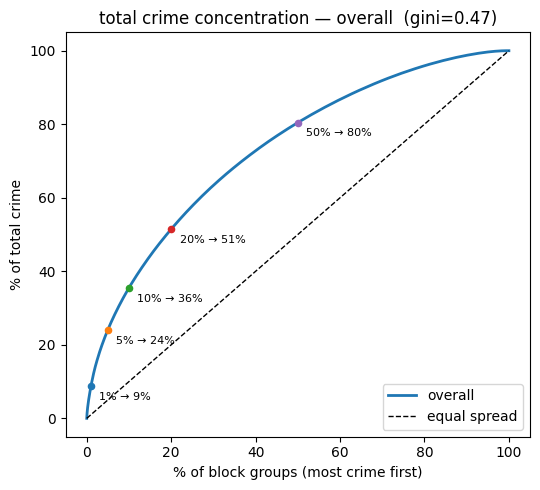

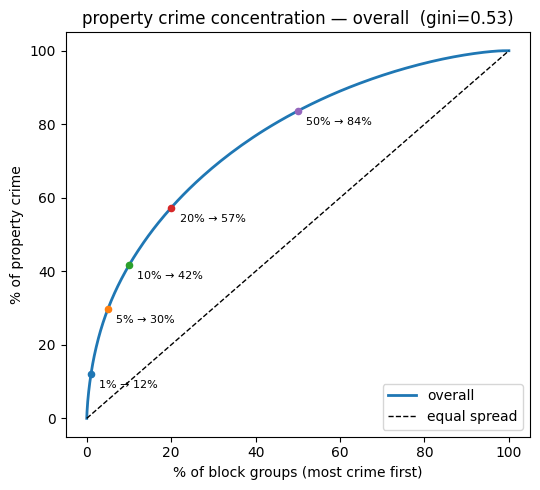

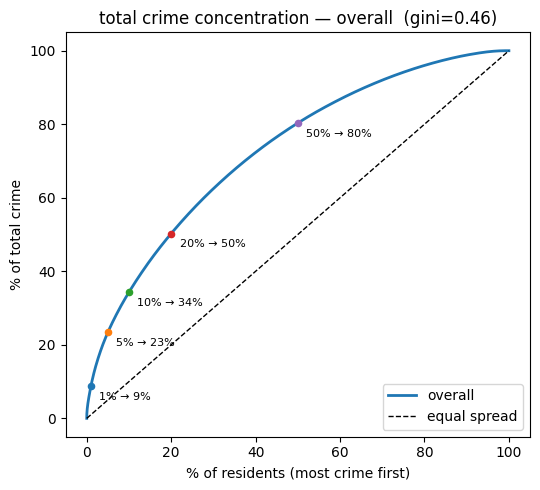

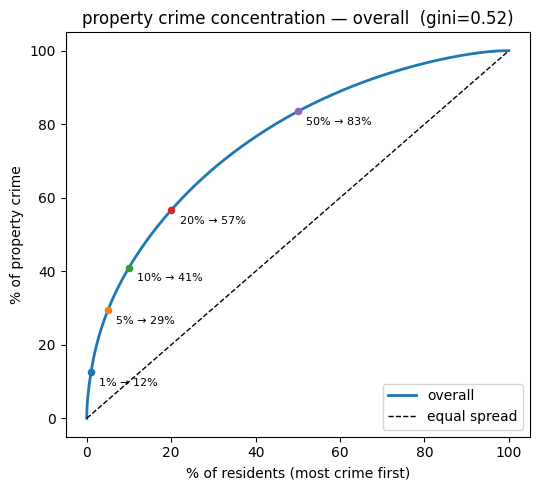

n_bg                      20054.000
crimes                   749623.000
zero_crime_bg_pct             0.900
gini                          0.524
crime_in_top1%_pop           12.500
crime_in_top5%_pop           29.400
crime_in_top10%_pop          41.000
crime_in_top20%_pop          56.600
crime_in_top50%_pop          83.500
pop_pct_for_25%_crime         3.600
pop_pct_for_50%_crime        15.300
pop_pct_for_80%_crime        44.700
Name: overall, dtype: float64

In [8]:
crime_concentration(scope="overall", crime="total")                          
crime_concentration(scope="overall", crime="property")
crime_concentration(scope="overall", crime="total", x_unit="population")     # share of residents instead of BGs
crime_concentration(scope="overall", crime="property", x_unit="population")     # share of residents instead of BGs

In [9]:
# View table in tabular format
display(concentration_table("property"))

,n_bg,crimes,zero_crime_bg_pct,gini,crime_in_top1%_bg,crime_in_top5%_bg,crime_in_top10%_bg,crime_in_top20%_bg,crime_in_top50%_bg,bg_pct_for_25%_crime,bg_pct_for_50%_crime,bg_pct_for_80%_crime
new_york,6438.0,172612.0,1.1,0.553,17.4,35.8,46.6,60.3,83.7,2.1,12.1,43.7
las_vegas,439.0,14798.0,0.2,0.548,9.5,30.5,43.4,58.6,85.1,3.6,13.9,42.2
dallas,861.0,39264.0,1.7,0.523,11.0,31.3,42.5,57.1,82.9,3.3,14.7,45.5
houston,1627.0,88079.0,3.1,0.552,9.9,28.9,42.1,58.9,85.5,3.9,14.1,41.7
overall,20054.0,749623.0,0.9,0.528,12.0,29.7,41.6,57.3,83.6,3.6,14.8,44.3
jacksonville,550.0,22787.0,1.1,0.553,11.9,28.9,41.4,57.9,86.2,3.8,14.8,41.0
san_francisco,676.0,27447.0,1.8,0.516,10.8,28.1,40.5,56.9,83.0,4.1,15.2,45.3
sacramento,366.0,11235.0,0.3,0.516,11.2,27.5,40.0,56.4,83.2,4.2,15.6,44.8
pittsburgh,306.0,8680.0,1.0,0.507,11.0,27.8,40.0,56.2,82.2,4.1,15.6,46.6
philadelphia,1297.0,62319.0,0.2,0.475,9.5,26.8,38.8,54.4,80.0,4.4,16.8,50.0


**Functions to Examine Predictors**

In [10]:
# --- apply chosen transforms and compare linear fit / VIF across versions ---
def apply_transform(x, kind):
    """Return (transformed series, yeo-johnson lambda or None)."""
    x = x.astype(float)
    if kind == "raw":
        return x, None
    if kind == "log1p":
        return np.log1p(x), None
    if kind == "sqrt":
        return np.sqrt(x), None
    if kind == "yeojohnson":
        nn = x.dropna()
        y, lam = stats.yeojohnson(nn)
        return pd.Series(y, index=nn.index).reindex(x.index), lam
    raise ValueError(f"unknown transform {kind!r}")

def add_best_transforms(family, override=None):
    """Add a `{var}__t` column to `pool` for each raw variable in the family, using
    skew_table's `best` unless overridden, e.g. override={"vacant_pct": "log1p"}."""
    st = skew_table(family)
    choice = {**st["best"].to_dict(), **(override or {})}
    rows = []
    for v, kind in choice.items():
        pool[f"{v}__t"], lam = apply_transform(pool[v], kind)
        rows.append({"variable": v, "transform": kind, "yj_lambda": lam,
                     "skew_raw": st.loc[v, "skew_raw"],
                     "skew_current": st.loc[v, "skew_model"],
                     "skew_new": _skew(pool[f"{v}__t"]),
                     "current_form": st.loc[v, "model_form"]})
    return pd.DataFrame(rows).set_index("variable").round(3)

def compare_forms(families, target="property"):
    """For raw / current model form / new transform: Pearson r with log1p(target)
    (pooled and median within-city) and VIF of that version's full set.
    `families` = one family name or a list (use a list to see cross-family VIF)."""
    families = [families] if isinstance(families, str) else families
    raw_cols = [c for f in families for c in FAMILIES[f]]
    t, cities = TARGETS[target]
    d = pool[pool["city"].isin(cities)].copy()
    d["_y"] = np.log1p(d[t])
    versions = {"raw":     raw_cols,
                "current": [model_form(c) for c in raw_cols],
                "new":     [f"{c}__t" for c in raw_cols]}
    out = {}
    for name, cols in versions.items():
        r_pooled = d[cols].corrwith(d["_y"])
        r_within = pd.DataFrame({city: g[cols].corrwith(g["_y"])
                                 for city, g in d.groupby("city")}).median(axis=1)
        vif = vif_table(d, list(dict.fromkeys(cols)))["vif"]
        out[name] = pd.DataFrame({"r_pooled": r_pooled.reindex(cols).values,
                                  "r_within": r_within.reindex(cols).values,
                                  "vif":      vif.reindex(cols).values}, index=raw_cols)
    return pd.concat(out, axis=1).round(2)

**Demographic Predictors**

In [52]:
fam = "demographic"            # demographic | property | transit | imagery | roadway
cols = model_cols(fam)

# Q1 + Q2 — missingness and skew numbers
display(skew_table(fam))

,pct_missing_raw,pct_zero,min,median,max,model_form,skew_raw,skew_model,skew_log1p,skew_sqrt,skew_yeojohnson,best,flag
variable,,,,,,,,,,,,,
moved1yr_pct,0.0,0.51,0.00,11.75,100.00,moved1yr_pct,1.55,1.55,-0.52,0.38,-0.00,yeojohnson,
own_pct,0.0,8.83,0.00,43.59,100.00,own_pct,0.12,0.12,-1.54,-0.73,-0.35,raw,
lap_pct,0.0,23.70,0.00,26.33,100.00,lap_pct,0.48,0.48,-0.54,-0.08,-0.24,sqrt,
city_centers_dist,0.0,0.00,1.00,15.00,50.00,city_centers_dist,1.10,1.10,-0.65,0.27,0.04,yeojohnson,
pop_est_5mile,0.0,0.00,2877.00,642653.00,3486951.00,pop_est_5mile_log,1.08,0.08,0.08,0.69,0.01,yeojohnson,
pop_ch_1mile,0.0,0.02,-95.68,2.95,61.13,pop_ch_1mile,-2.37,-2.37,NaN,NaN,0.10,yeojohnson,
in_household_pct,0.0,0.14,0.00,99.75,100.00,in_household_pct,-7.85,-7.85,-16.82,-11.48,-1.64,yeojohnson,
det_pct,0.0,22.73,0.00,15.03,100.00,det_pct,0.80,0.80,-0.30,0.21,-0.12,yeojohnson,


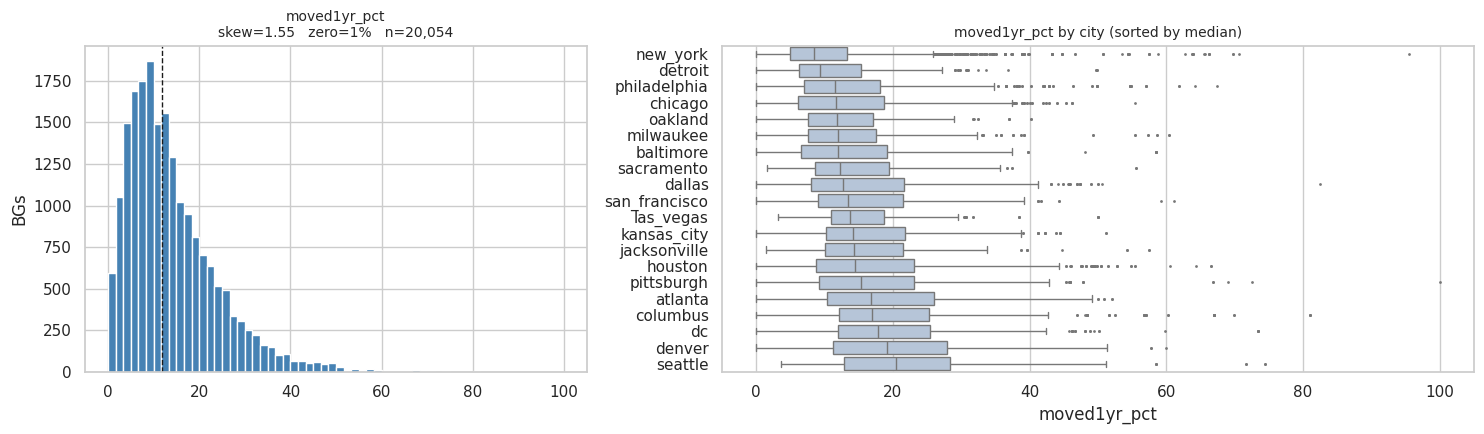

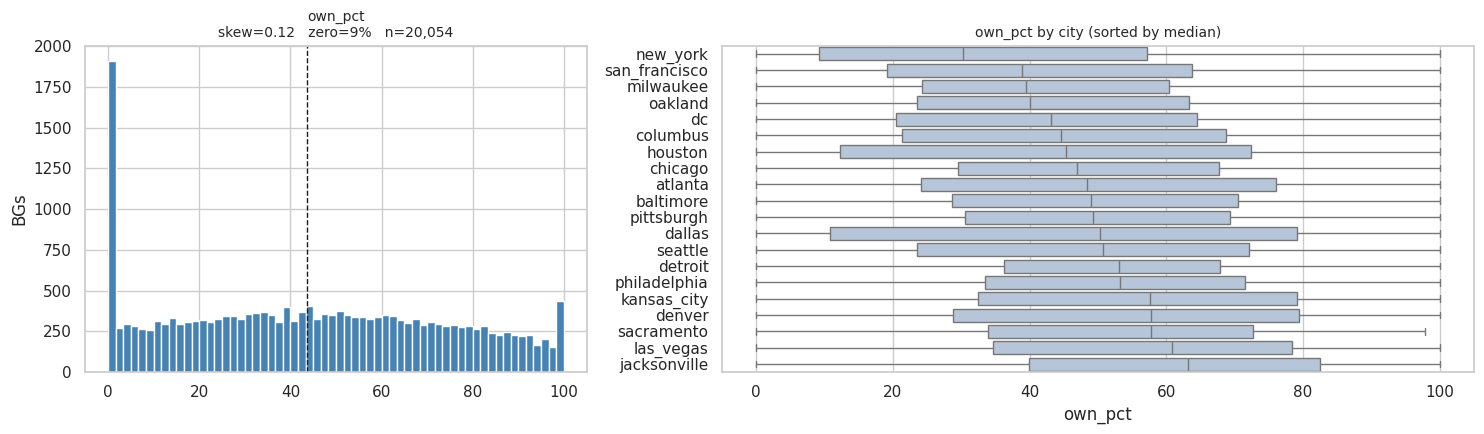

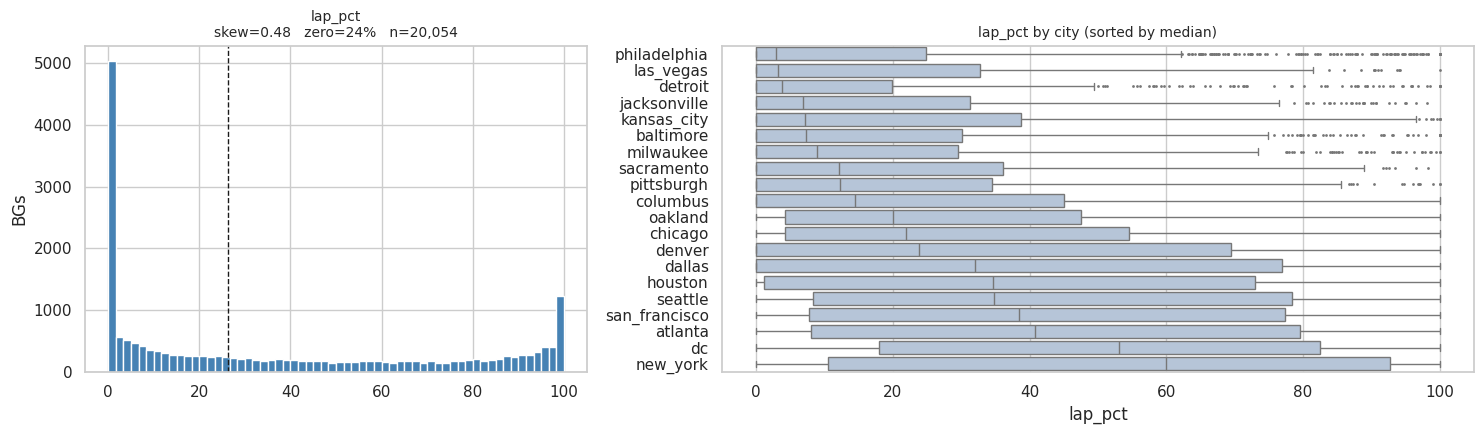

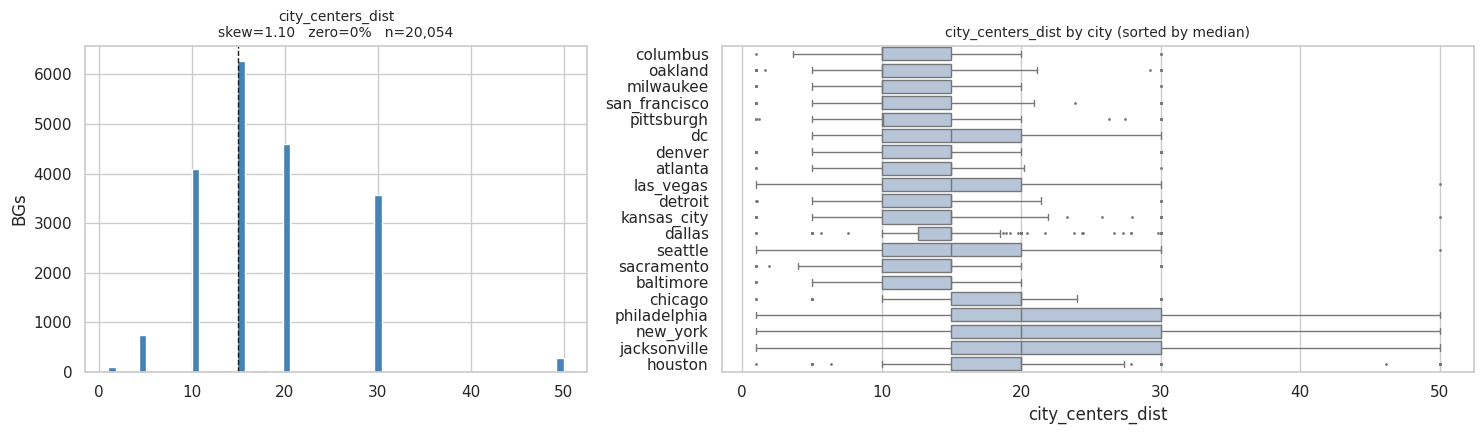

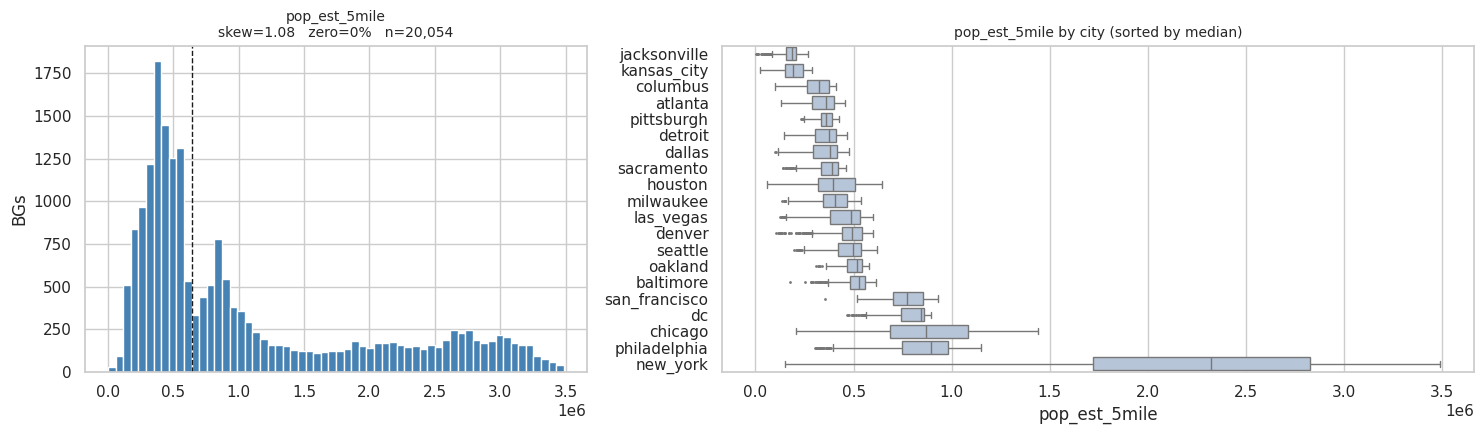

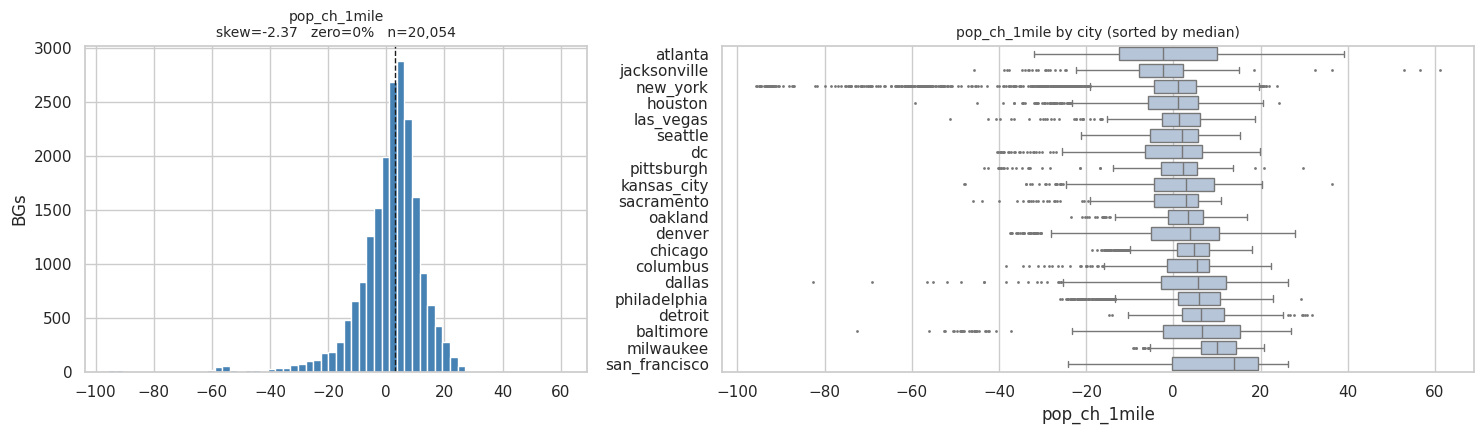

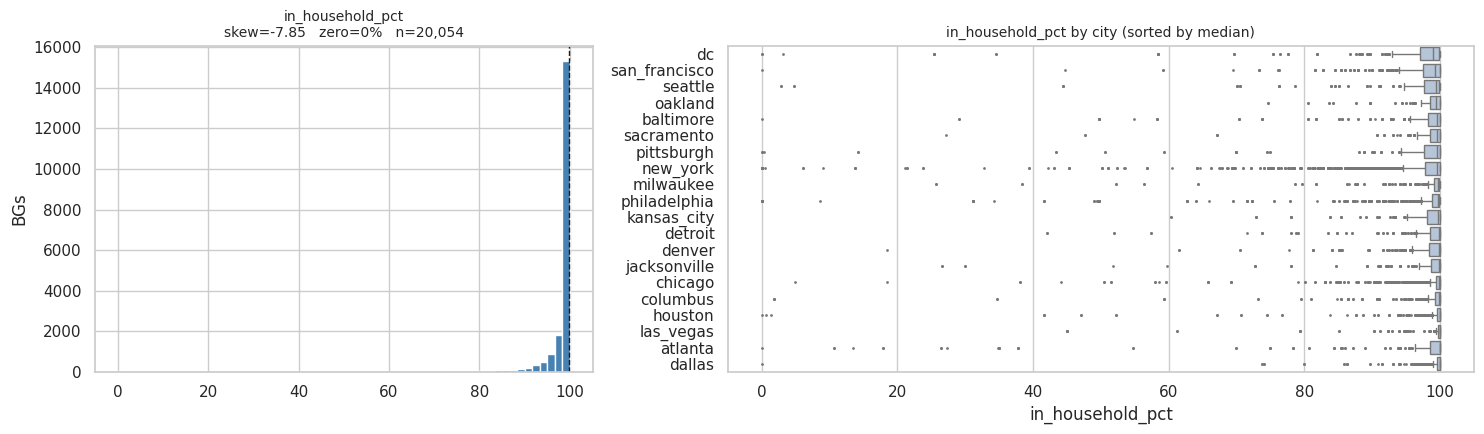

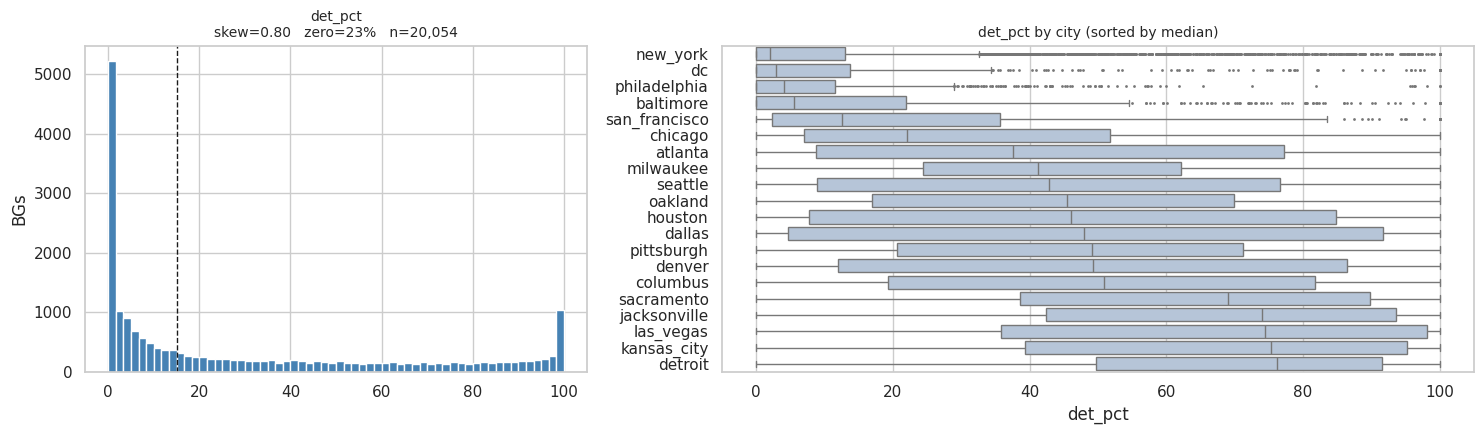

In [54]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'lap_pct'
#plot_dist(v,transform=None)

for v in FAMILIES[fam]:
    plot_dist(v,transform=None) # e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

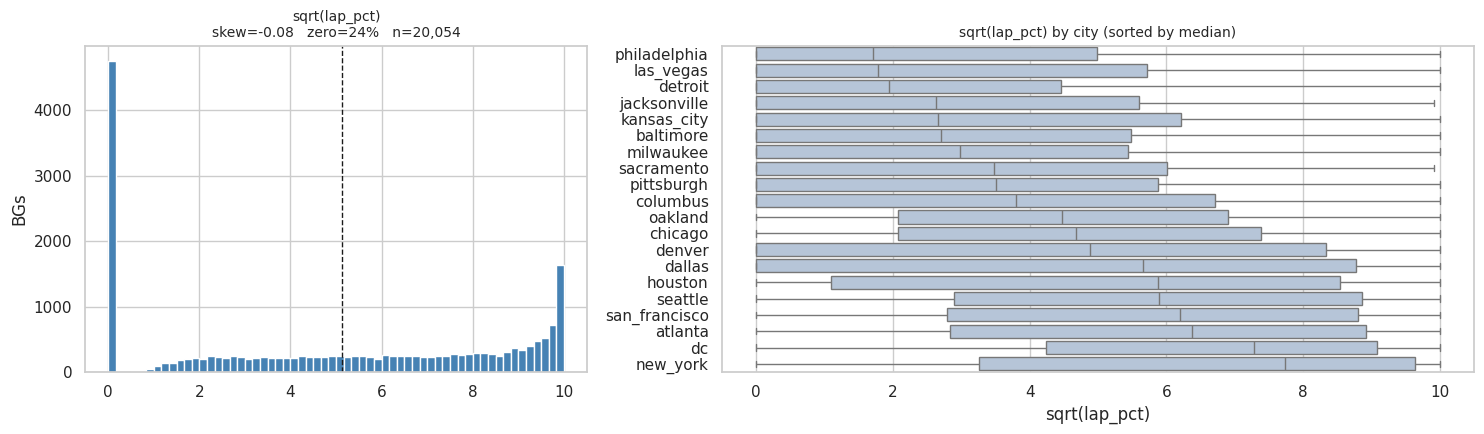

In [29]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'in_household_pct'
plot_dist(v,transform='sqrt')

#for v in FAMILIES[fam]:
#    plot_dist(v)
# e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

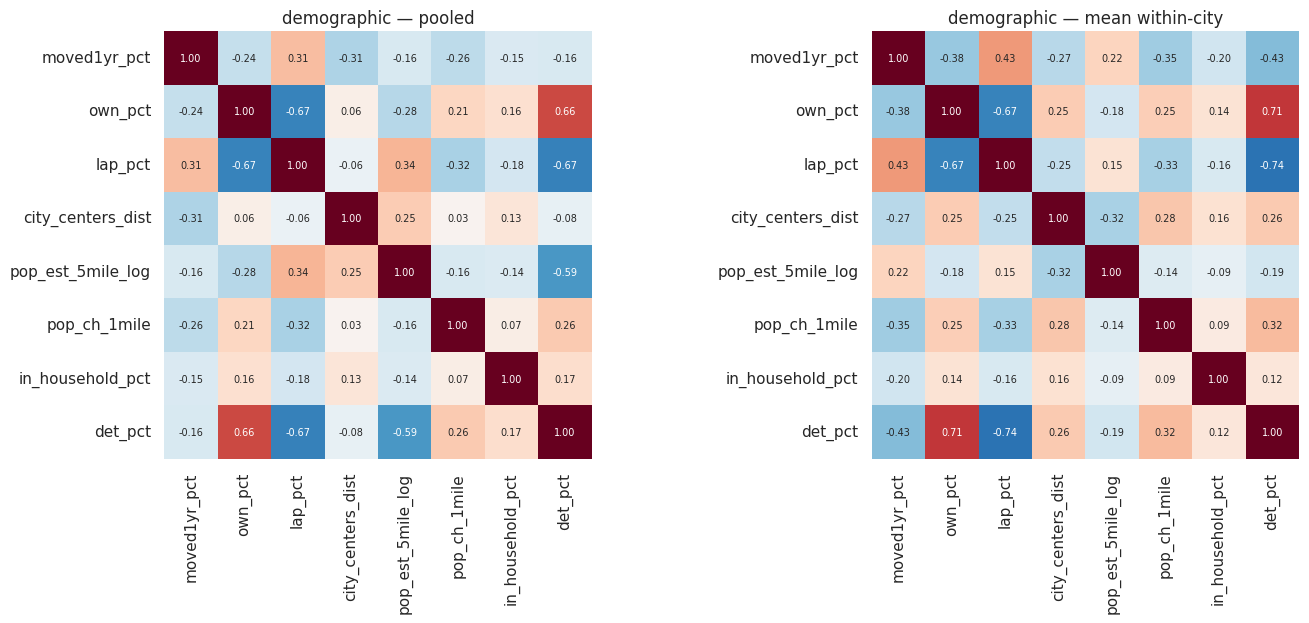

,a,b,within_rho,pooled_rho
2,lap_pct,det_pct,-0.74,-0.67
1,own_pct,det_pct,0.71,0.66
0,own_pct,lap_pct,-0.67,-0.67


In [23]:
# Q3 — predictor–predictor correlation
corr_heatmaps(cols, fam)
display(top_pairs(cols, thresh=0.5))

In [24]:
display(vif_table(pool, cols))

,vif
predictor,
det_pct,2.698630
lap_pct,2.281190
own_pct,2.200842
pop_est_5mile_log,1.725555
moved1yr_pct,1.649870
in_household_pct,1.234262
pop_ch_1mile,1.158623
city_centers_dist,1.153516


total                                        property  \
                  pooled within_med sign_agree between n_cities   pooled   
own_pct            -0.30      -0.34        1.0    0.27       10    -0.13   
det_pct            -0.11      -0.19        1.0    0.53       10     0.04   
city_centers_dist  -0.14      -0.18        0.6   -0.43       10    -0.32   
lap_pct             0.03       0.12        0.8   -0.75       10    -0.01   
moved1yr_pct        0.02       0.07        0.7   -0.49       10     0.25   
pop_est_5mile_log  -0.08       0.10        0.6   -0.35       10    -0.27   
in_household_pct   -0.10      -0.10        0.9   -0.13       10    -0.08   
pop_ch_1mile       -0.00      -0.04        0.6    0.70       10     0.03   

                                                                   all  
                  within_med sign_agree between n_cities between_share  
own_pct                -0.35       1.00    0.00       20          0.06  
det_pct                -0.29       0.95    0.07       20          0.33  
city_centers_dist      -0.25       0.85   -0.22       20          0.23  
lap_pct                 0.23       0.95   -0.17       20          0.14  
moved1yr_pct            0.20       0.95   -0.06       20          0.12  
pop_est_5mile_log       0.14       0.90    0.04       20          0.82  
in_household_pct       -0.12       0.90   -0.14       20          0.01  
pop_ch_1mile           -0.11       0.85    0.42       20          0.08

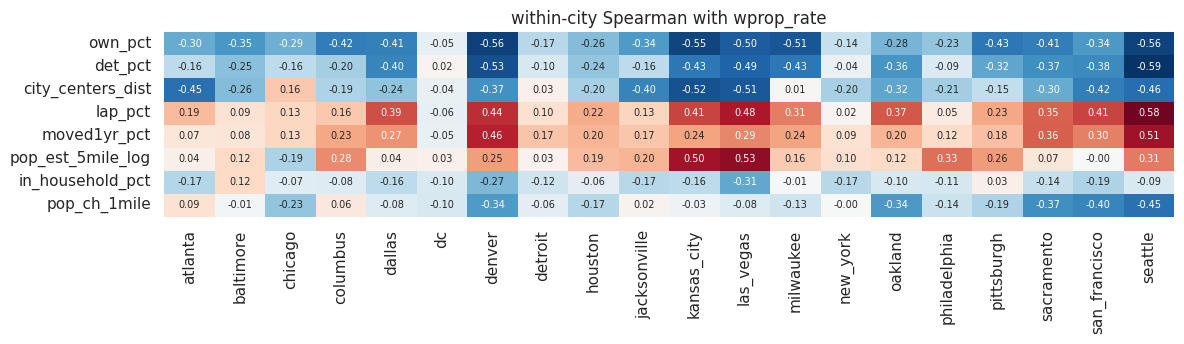

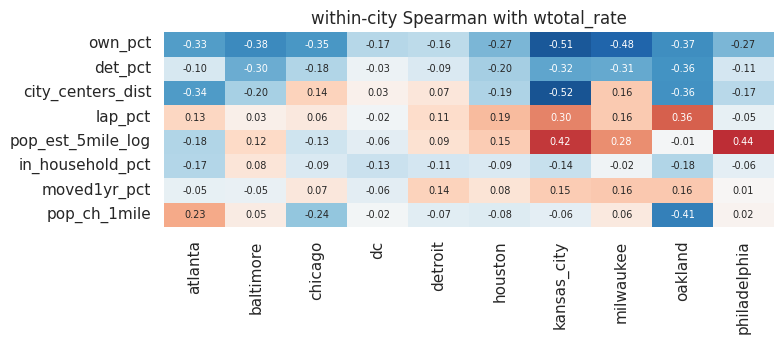

In [25]:
# Q4 — correlation with crime, pooled / within / between cities
display(target_corr_table(cols))
city_corr_heatmap(cols, "property")
city_corr_heatmap(cols, "total")

**Key Observations:**
1. Feature transformation doesn't matter much for a LightGBM model (tried running the Yeo-Johnson transform but doesn't matter beyond a linear model)
2. Neither do correlations, but we will still flag variables that are say, highly correlated to other predictors but don't have any unique signals with crime
3. In this case, that variable is **det_pct**

**Property family**

In [55]:
fam = "property"            # demographic | property | transit | imagery | roadway
cols = model_cols(fam)

# Q1 + Q2 — missingness and skew numbers
display(skew_table(fam))

,pct_missing_raw,pct_zero,min,median,max,model_form,skew_raw,skew_model,skew_log1p,skew_sqrt,skew_yeojohnson,best,flag
variable,,,,,,,,,,,,,
vacant_pct,0.37,9.04,0.0,1.52,100.00,vacant_pct_log,4.21,0.82,0.82,1.45,0.11,yeojohnson,
clip_liens_pct,0.34,71.46,0.0,0.00,100.00,clip_liens_pct_log,9.12,3.89,3.89,4.27,1.23,yeojohnson,zero-inflated: consider has_X flag + log1p
clip_foreclosure_pct,1.51,44.60,0.0,0.42,100.00,clip_foreclosure_pct_log,7.66,1.18,1.18,1.33,0.35,yeojohnson,zero-inflated: consider has_X flag + log1p
clip_transaction_pct,0.34,1.51,0.0,49.26,100.00,clip_transaction_pct_log,-0.46,-4.97,-4.97,-2.46,0.02,yeojohnson,
unq_convenience_stores_clips,0.34,53.26,0.0,0.00,41.00,unq_convenience_stores_clips,5.95,5.95,0.85,0.73,0.32,yeojohnson,zero-inflated: consider has_X flag + log1p
unq_gas_stations_clips,0.34,75.00,0.0,0.00,16.00,unq_gas_stations_clips,4.39,4.39,1.73,1.55,1.16,yeojohnson,zero-inflated: consider has_X flag + log1p
unq_liquor_stores_clips,0.34,81.58,0.0,0.00,15.00,unq_liquor_stores_clips,4.28,4.28,2.00,1.85,1.63,yeojohnson,zero-inflated: consider has_X flag + log1p
vacant_pct_lag6,0.31,1.21,0.0,1.77,52.52,vacant_pct_lag6_log,3.60,0.85,0.85,1.53,0.08,yeojohnson,
clip_liens_pct_lag6,0.34,38.90,0.0,0.07,40.03,clip_liens_pct_lag6_log,7.77,4.05,4.05,4.22,0.86,yeojohnson,zero-inflated: consider has_X flag + log1p


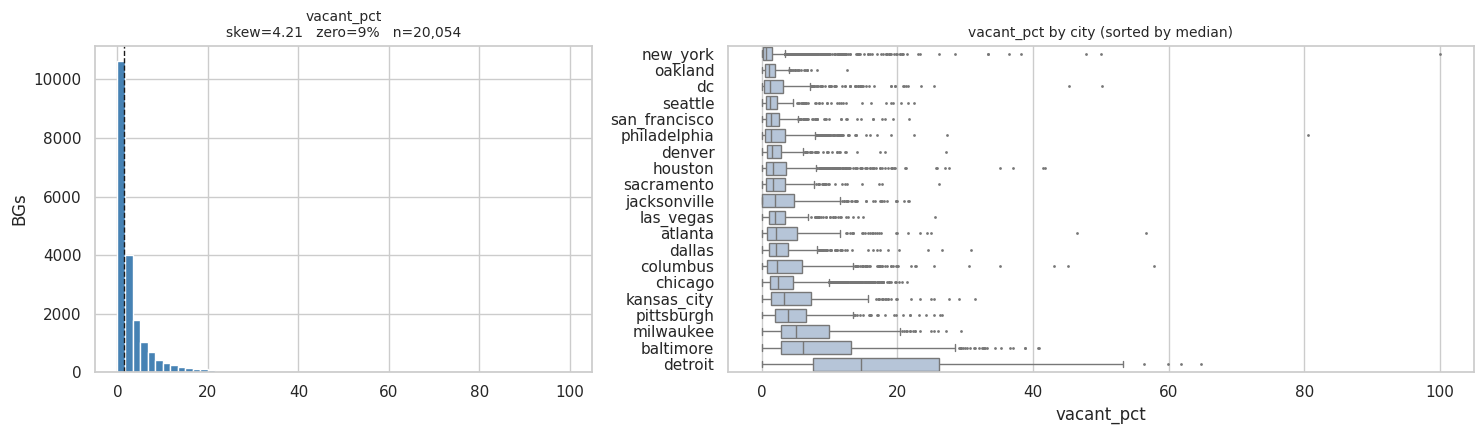

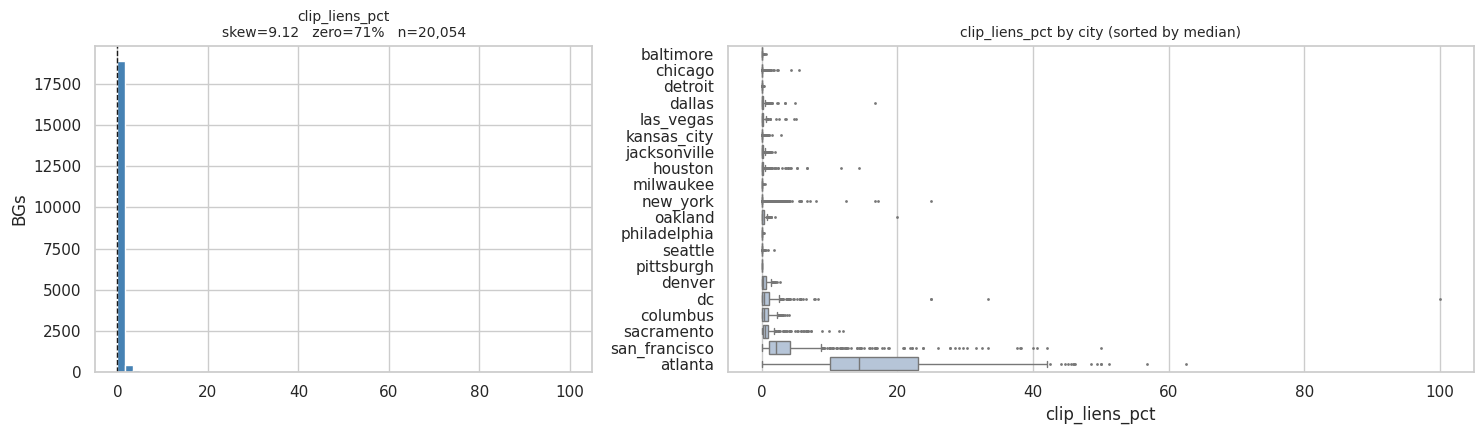

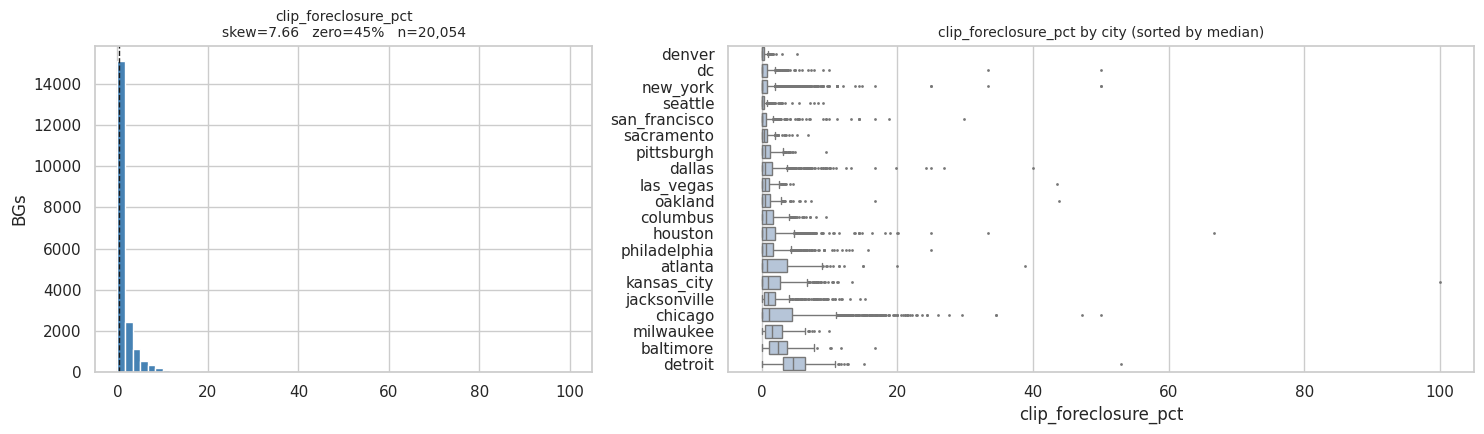

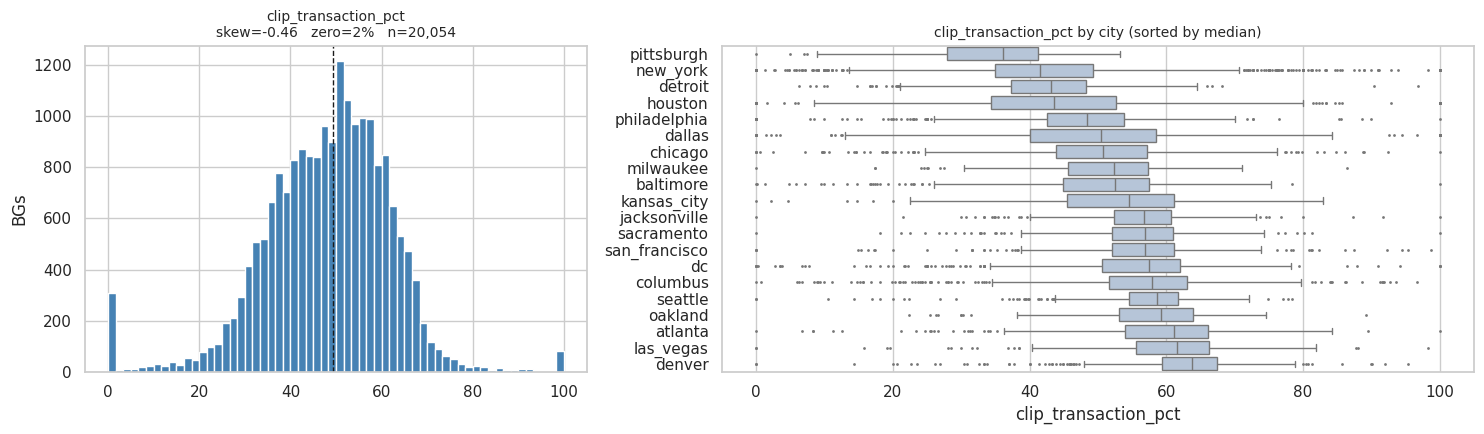

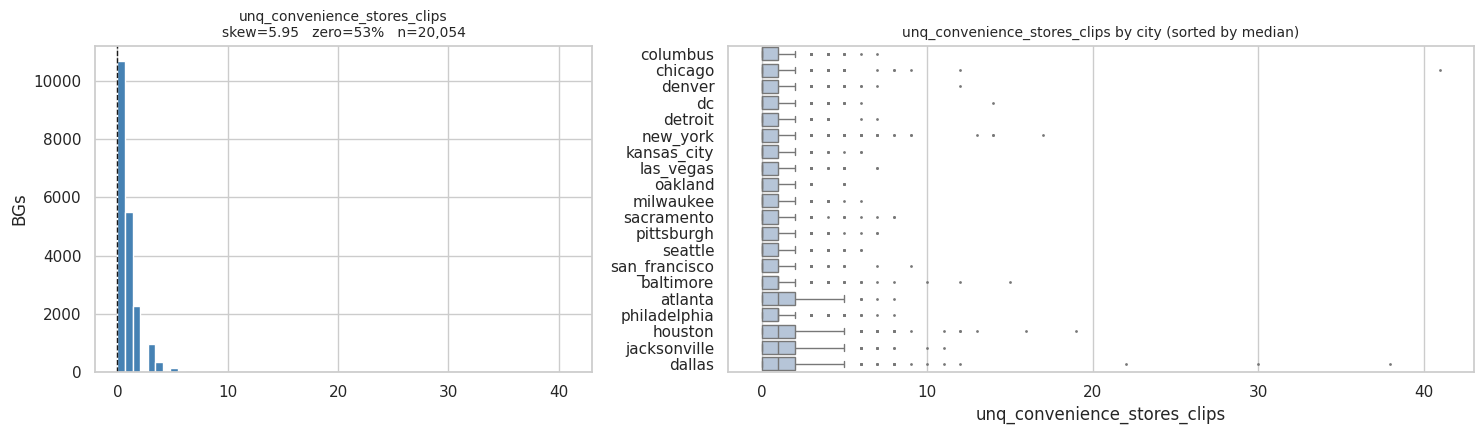

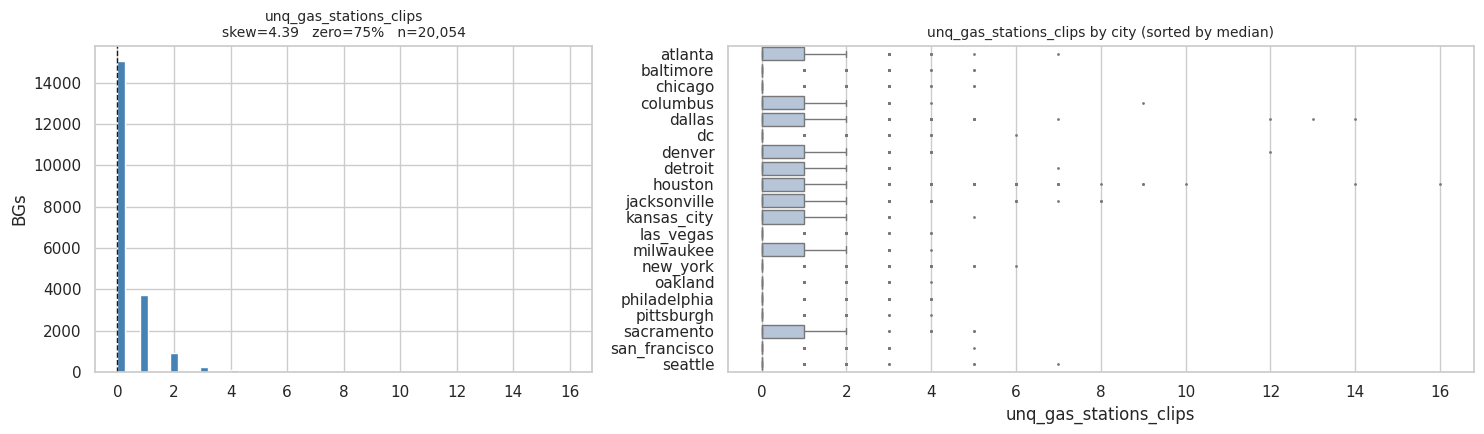

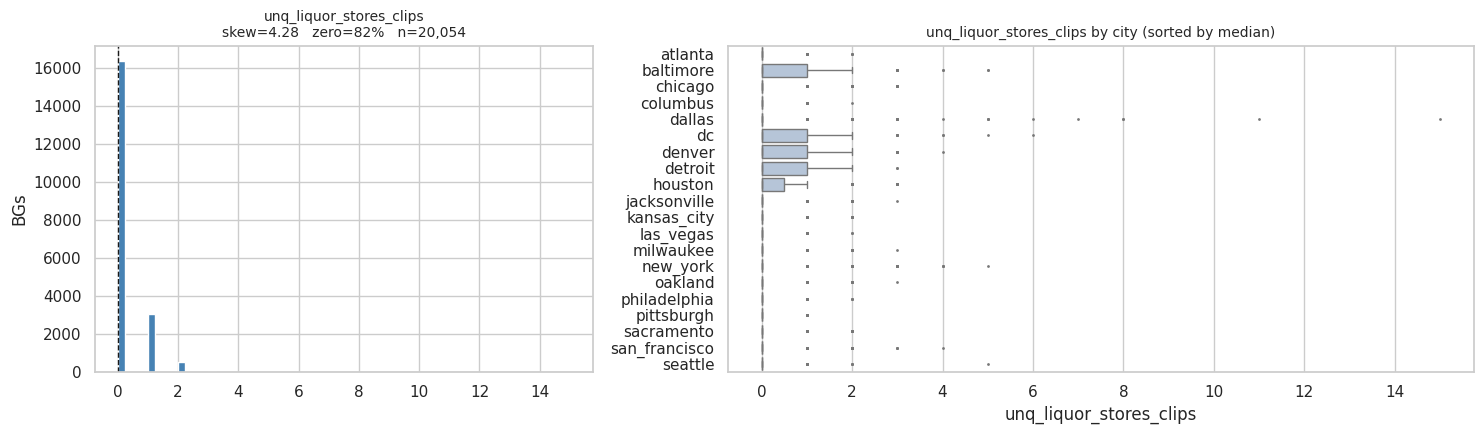

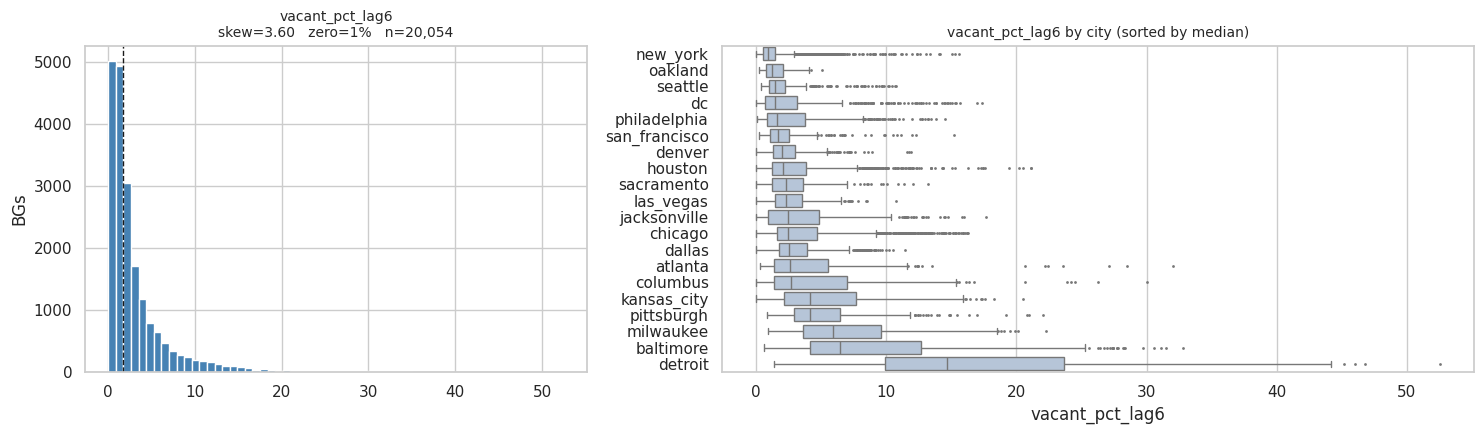

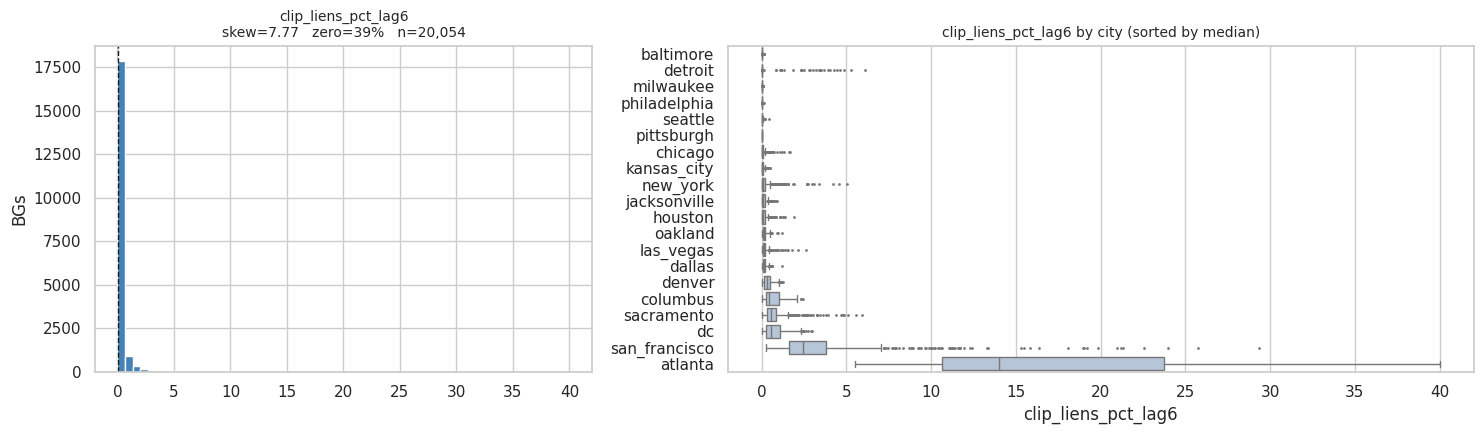

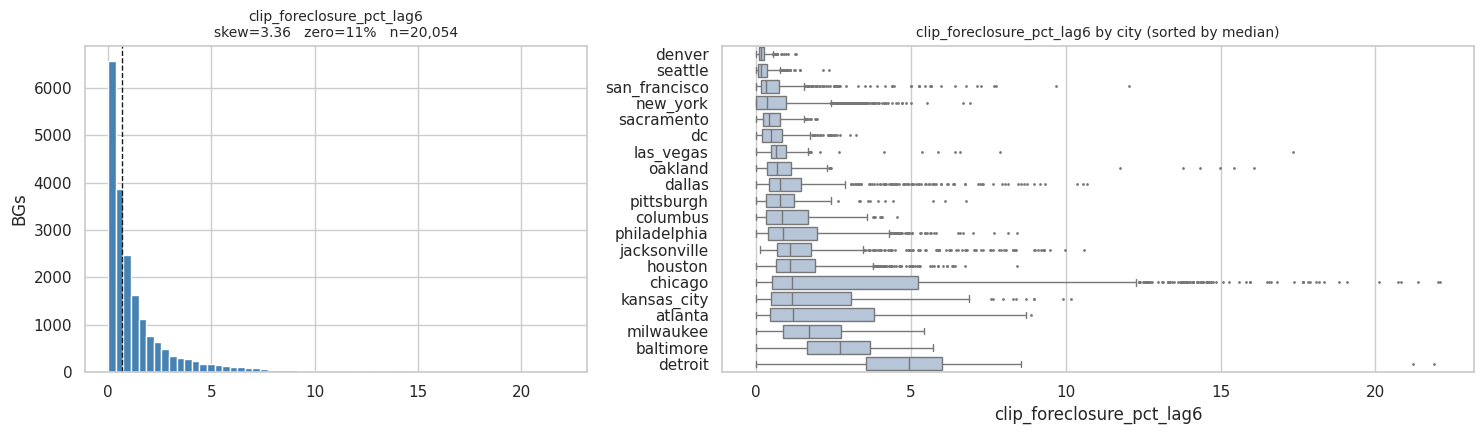

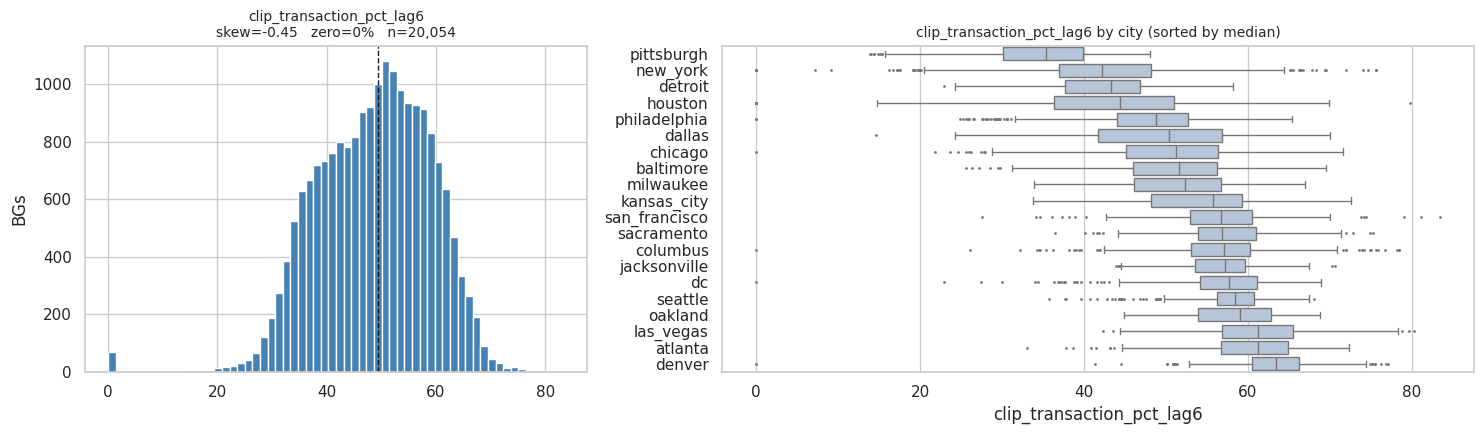

In [56]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'lap_pct'
#plot_dist(v,transform=None)

for v in FAMILIES[fam]:
    plot_dist(v,transform=None) # e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

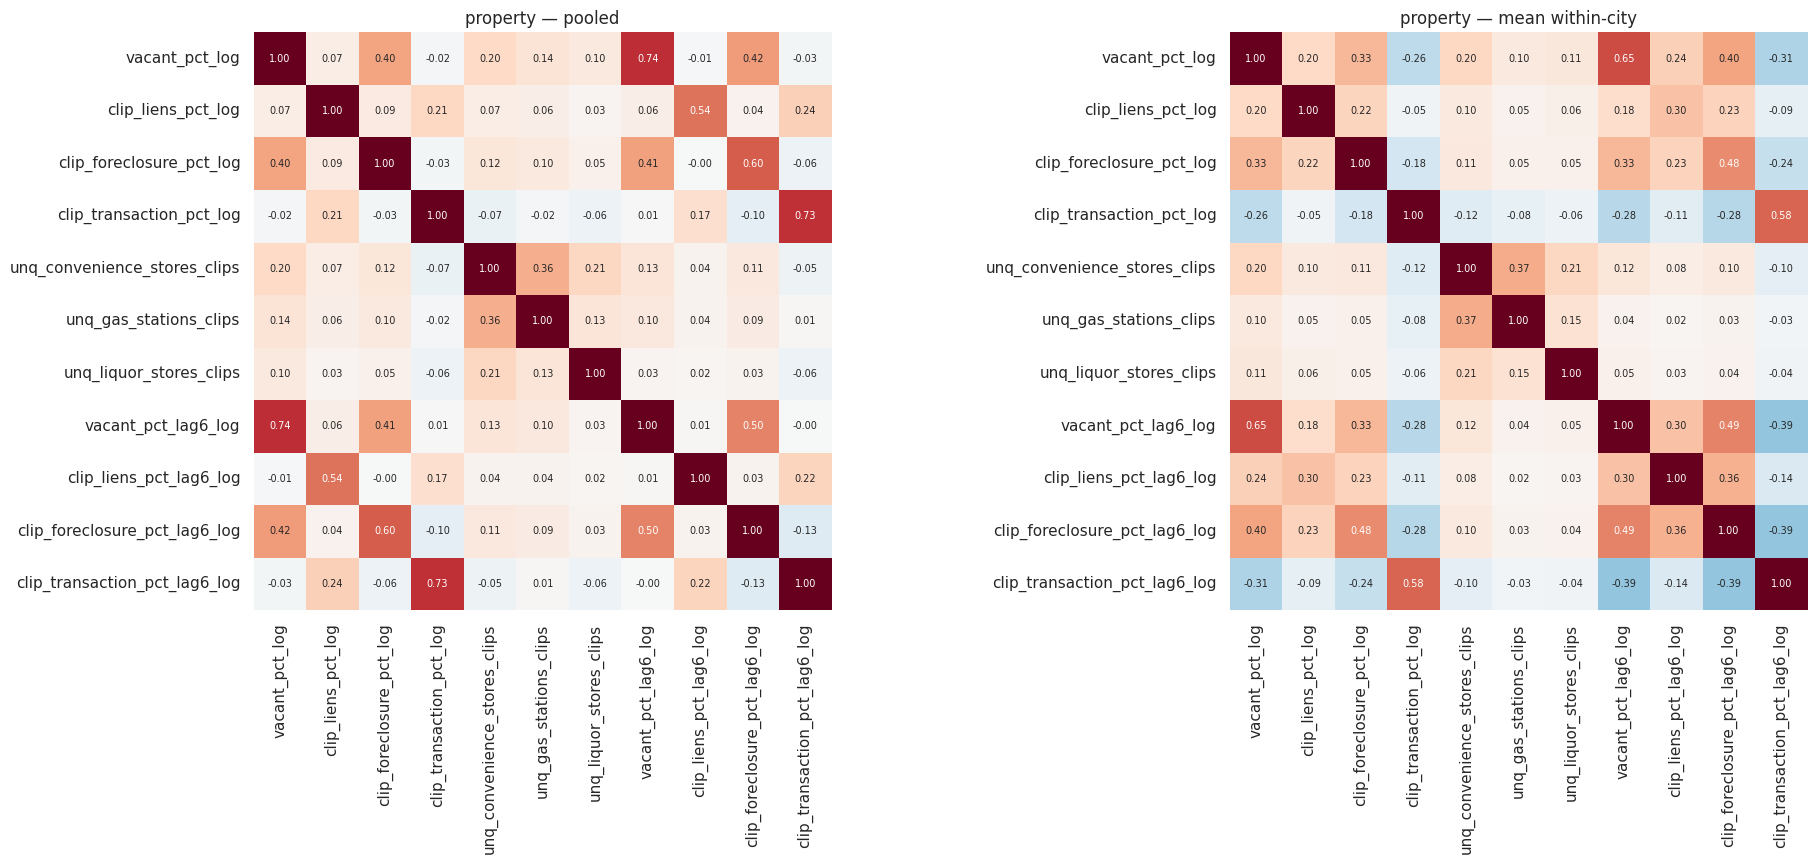

,a,b,within_rho,pooled_rho
0,vacant_pct_log,vacant_pct_lag6_log,0.65,0.74
1,clip_transaction_pct_log,clip_transaction_pct_lag6_log,0.58,0.73


In [57]:
 # Q3 — predictor–predictor correlation
corr_heatmaps(cols, fam)
display(top_pairs(cols, thresh=0.5))

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


total                                         \
                              pooled within_med sign_agree between n_cities   
vacant_pct_log                  0.50       0.48        1.0    0.70       10   
vacant_pct_lag6_log             0.47       0.47        1.0    0.71       10   
unq_convenience_stores_clips    0.24       0.26        1.0   -0.07       10   
clip_foreclosure_pct_lag6_log   0.45       0.39        1.0    0.72       10   
unq_gas_stations_clips          0.17       0.20        1.0     NaN       10   
clip_transaction_pct_log       -0.29      -0.35        0.9   -0.32       10   
clip_foreclosure_pct_log        0.37       0.29        1.0    0.71       10   
clip_transaction_pct_lag6_log  -0.31      -0.40        0.8   -0.33       10   
clip_liens_pct_lag6_log        -0.00       0.11        0.7   -0.73       10   
unq_liquor_stores_clips         0.16       0.15        1.0     NaN       10   
clip_liens_pct_log              0.00       0.05        0.8   -0.59       10   

                              property                                         \
                                pooled within_med sign_agree between n_cities   
vacant_pct_log                    0.46       0.35       1.00    0.16       20   
vacant_pct_lag6_log               0.45       0.33       1.00    0.14       20   
unq_convenience_stores_clips      0.22       0.28       1.00    0.02       20   
clip_foreclosure_pct_lag6_log     0.28       0.24       1.00    0.29       20   
unq_gas_stations_clips            0.21       0.22       1.00     NaN       20   
clip_transaction_pct_log          0.06      -0.20       0.90    0.13       20   
clip_foreclosure_pct_log          0.25       0.14       0.95    0.32       20   
clip_transaction_pct_lag6_log     0.12      -0.14       0.80    0.10       20   
clip_liens_pct_lag6_log          -0.00       0.14       0.89   -0.36       19   
unq_liquor_stores_clips           0.09       0.13       1.00     NaN       20   
clip_liens_pct_log                0.06       0.07       0.89   -0.22       19   

                                        all  
                              between_share  
vacant_pct_log                         0.31  
vacant_pct_lag6_log                    0.43  
unq_convenience_stores_clips           0.05  
clip_foreclosure_pct_lag6_log          0.32  
unq_gas_stations_clips                 0.07  
clip_transaction_pct_log               0.10  
clip_foreclosure_pct_log               0.23  
clip_transaction_pct_lag6_log          0.23  
clip_liens_pct_lag6_log                0.84  
unq_liquor_stores_clips                0.03  
clip_liens_pct_log                     0.71

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


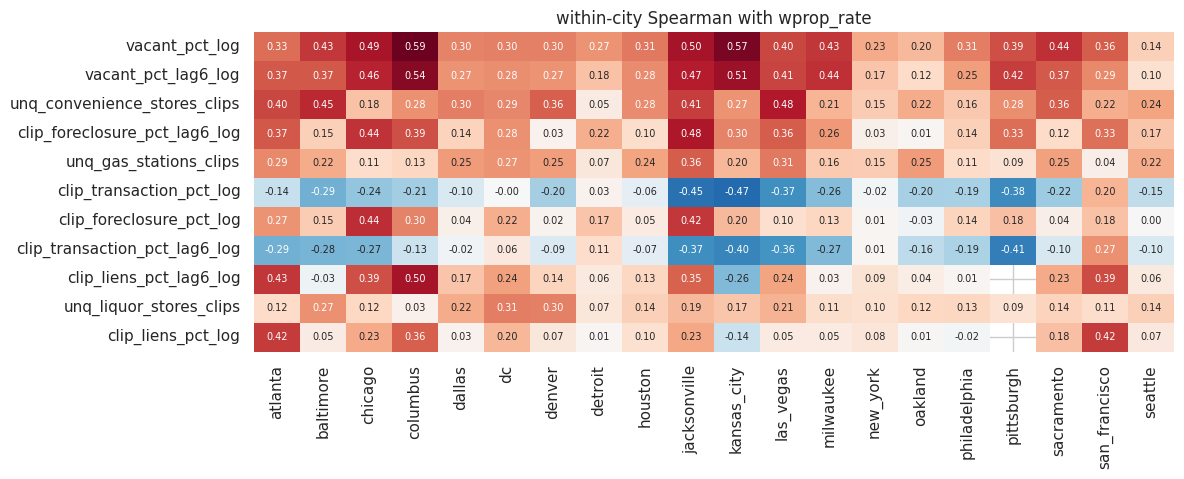

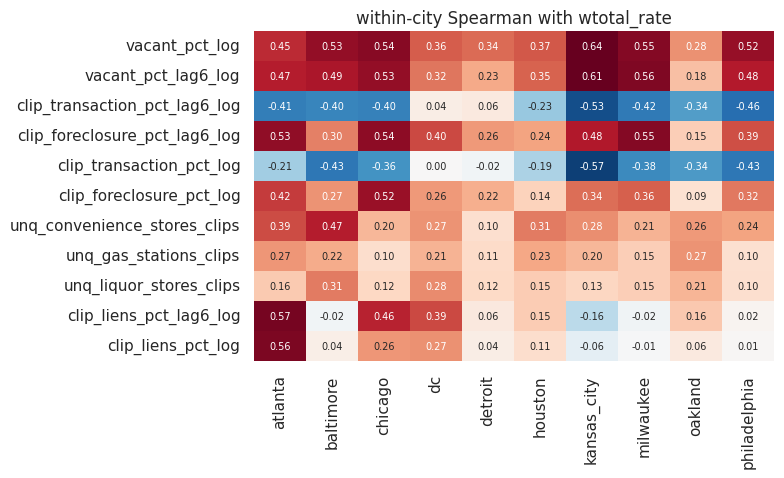

In [58]:
# Q4 — correlation with crime, pooled / within / between cities
display(target_corr_table(cols))
city_corr_heatmap(cols, "property")
city_corr_heatmap(cols, "total")

**Key Observations:**
1. Liens calculation is likely incorrect AND/OR the data isn't sourced correctly. Need to remove it.
2. Foreclosures will perhaps be more effective with the spatial lag feature; retain that
3. Vacany is powerful by itself and has a strong correlation with its spatial lag; can retain just the base feature. Although spatial lag may help in compliance because it is pooled.
4. Convenience store seems to be providing some lift for property crime but need to think through this more deeply
    * The underlying hypothesis is these coordinates are ideal locations of crime, especially in sparsely populated areas 
        * heavily populated will likely invite unreported, petty crime

**Imagery Family**

In [59]:
fam = "imagery"            # demographic | property | transit | imagery | roadway
cols = model_cols(fam)

# Q1 + Q2 — missingness and skew numbers
display(skew_table(fam))

,pct_missing_raw,pct_zero,min,median,max,model_form,skew_raw,skew_model,skew_log1p,skew_sqrt,skew_yeojohnson,best,flag
variable,,,,,,,,,,,,,
roof_condition_avg,0.38,0.00,1.96,3.58,5.00,roof_condition_avg,0.27,0.27,-0.01,0.09,0.00,yeojohnson,
roof_debris_pct_avg,0.38,12.59,0.00,0.07,4.82,roof_debris_pct_avg,5.45,5.45,2.90,1.28,0.39,yeojohnson,
hardscapes_pct_avg,0.38,0.06,0.00,7.50,34.69,hardscapes_pct_avg,0.56,0.56,-0.76,-0.23,-0.06,yeojohnson,
roof_missing_material_pct,7.17,18.30,0.00,0.27,1.00,roof_missing_material_pct,0.89,0.89,0.46,-0.35,0.06,yeojohnson,


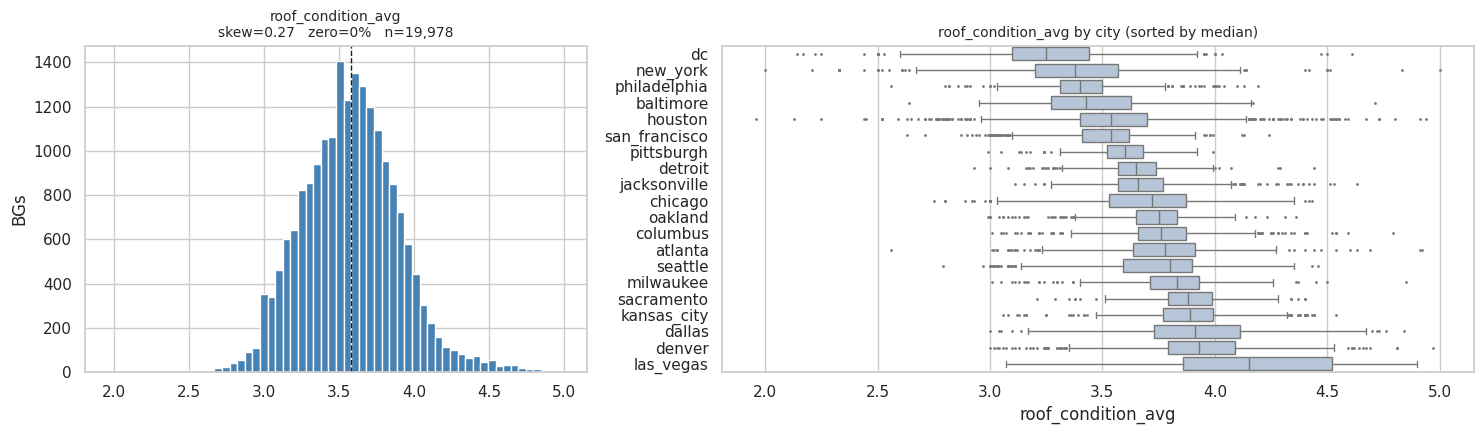

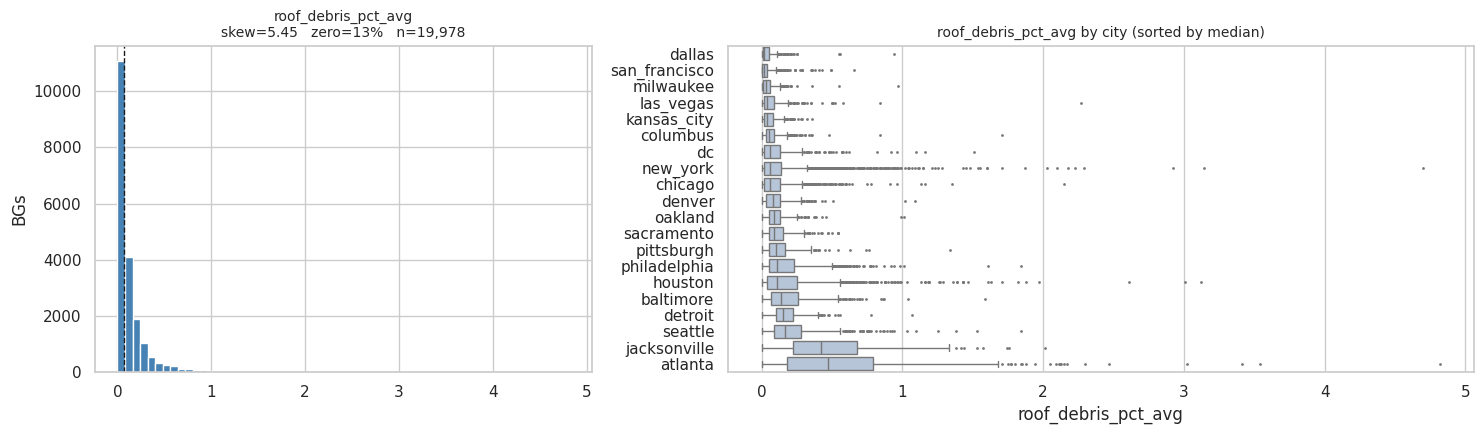

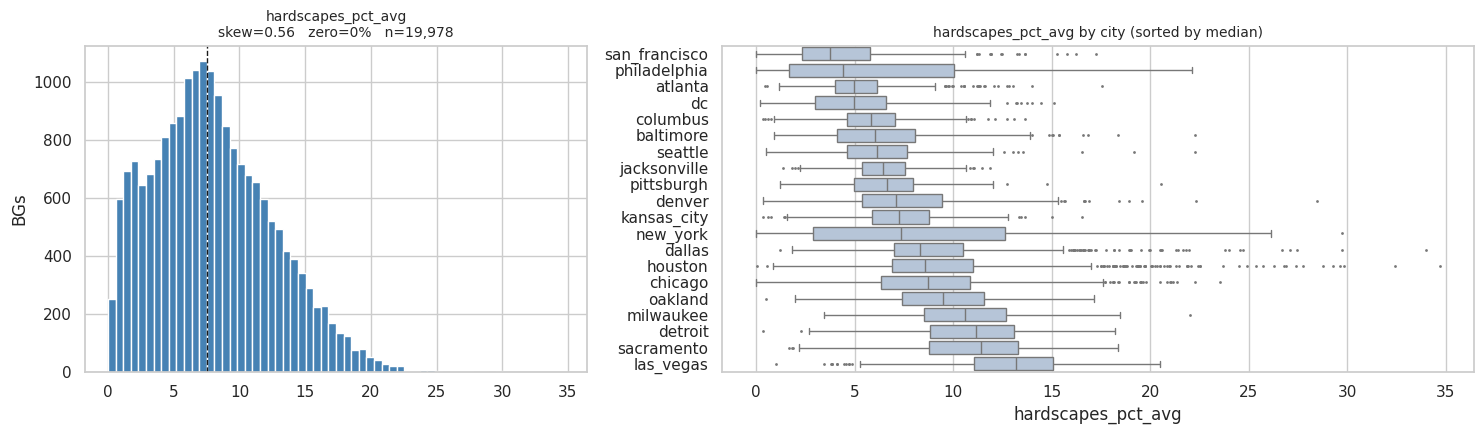

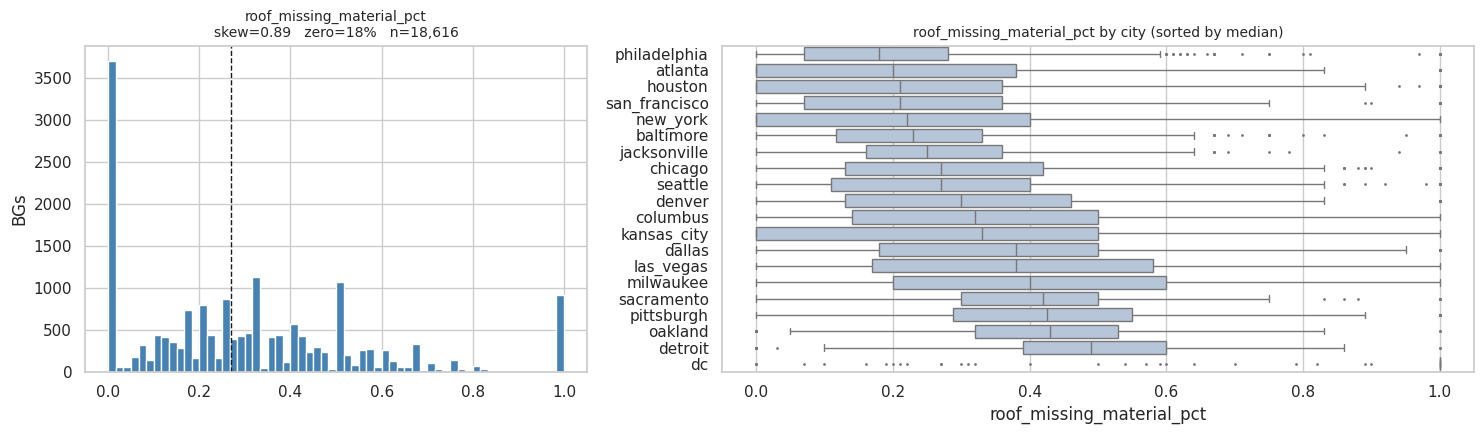

In [60]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'lap_pct'
#plot_dist(v,transform=None)

for v in FAMILIES[fam]:
    plot_dist(v,transform=None) # e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

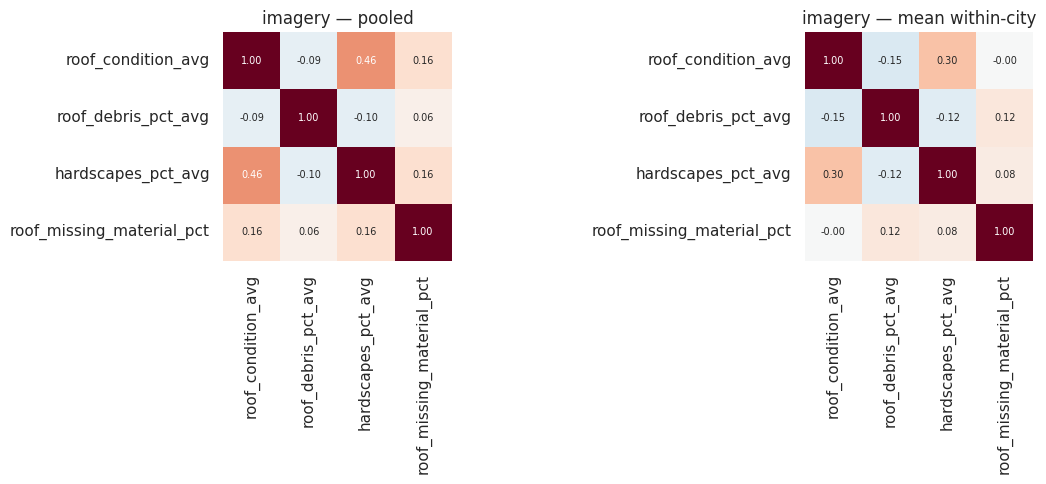

,a,b,within_rho,pooled_rho
0,roof_condition_avg,hardscapes_pct_avg,0.3,0.46


In [62]:
 # Q3 — predictor–predictor correlation
corr_heatmaps(cols, fam)
display(top_pairs(cols, thresh=0.2))

total                                         \
                          pooled within_med sign_agree between n_cities   
roof_condition_avg         -0.16      -0.26        0.9    0.26       10   
hardscapes_pct_avg         -0.08      -0.12        0.8    0.49       10   
roof_debris_pct_avg         0.18       0.19        0.7    0.13       10   
roof_missing_material_pct   0.08       0.10        0.9    0.15       10   

                          property                                         \
                            pooled within_med sign_agree between n_cities   
roof_condition_avg            0.06      -0.23       0.95    0.12       20   
hardscapes_pct_avg           -0.11      -0.20       0.80   -0.01       20   
roof_debris_pct_avg           0.14       0.08       0.70    0.19       20   
roof_missing_material_pct     0.06       0.03       0.55    0.03       20   

                                    all  
                          between_share  
roof_condition_avg                 0.42  
hardscapes_pct_avg                 0.14  
roof_debris_pct_avg                0.23  
roof_missing_material_pct          0.25

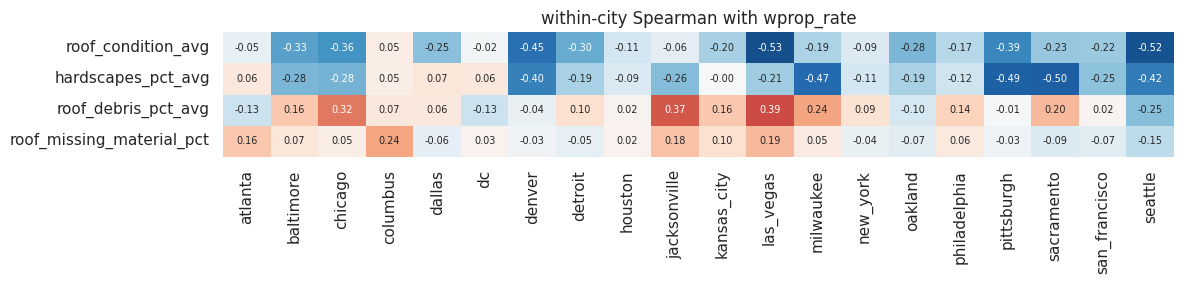

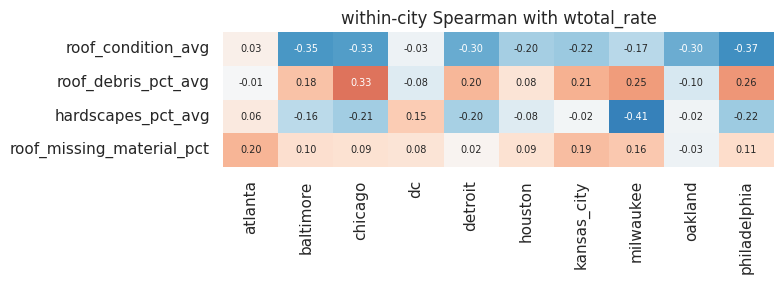

In [63]:
# Q4 — correlation with crime, pooled / within / between cities
display(target_corr_table(cols))
city_corr_heatmap(cols, "property")
city_corr_heatmap(cols, "total")

**Key Observations:**
1. Missing material seems to be a pretty useless feature
2. Can we try to add parking lots as a feature - should have high correlations with property crime. Especially relevant if we are training each model separately

**Roadway Family**

In [69]:
fam = "roadway"            # demographic | property | transit | imagery | roadway
cols = model_cols(fam)

# Q1 + Q2 — missingness and skew numbers
display(skew_table(fam))

,pct_missing_raw,pct_zero,min,median,max,model_form,skew_raw,skew_model,skew_log1p,skew_sqrt,skew_yeojohnson,best,flag
variable,,,,,,,,,,,,,
roadway_nearest_ramp_m,0.0,0.00,0.18,938.51,12868.49,roadway_nearest_ramp_m_log,1.96,-0.99,-0.99,0.51,-0.01,yeojohnson,
roadway_nearest_interstate_m,0.0,0.00,0.41,1165.61,12894.04,roadway_nearest_interstate_m_log,1.68,-0.89,-0.89,0.54,-0.03,yeojohnson,
roadway_ramp_count,0.0,82.05,0.00,0.00,166.00,roadway_ramp_count_log,12.50,2.73,2.73,3.37,1.68,yeojohnson,zero-inflated: consider has_X flag + log1p
roadway_arterial_density,0.0,18.48,0.00,1.80,44.63,roadway_arterial_density_log,2.34,0.26,0.26,0.43,0.04,yeojohnson,
roadway_intersection_density,0.0,0.15,0.00,85.55,686.18,roadway_intersection_density_log,1.45,-1.02,-1.02,0.32,0.00,yeojohnson,


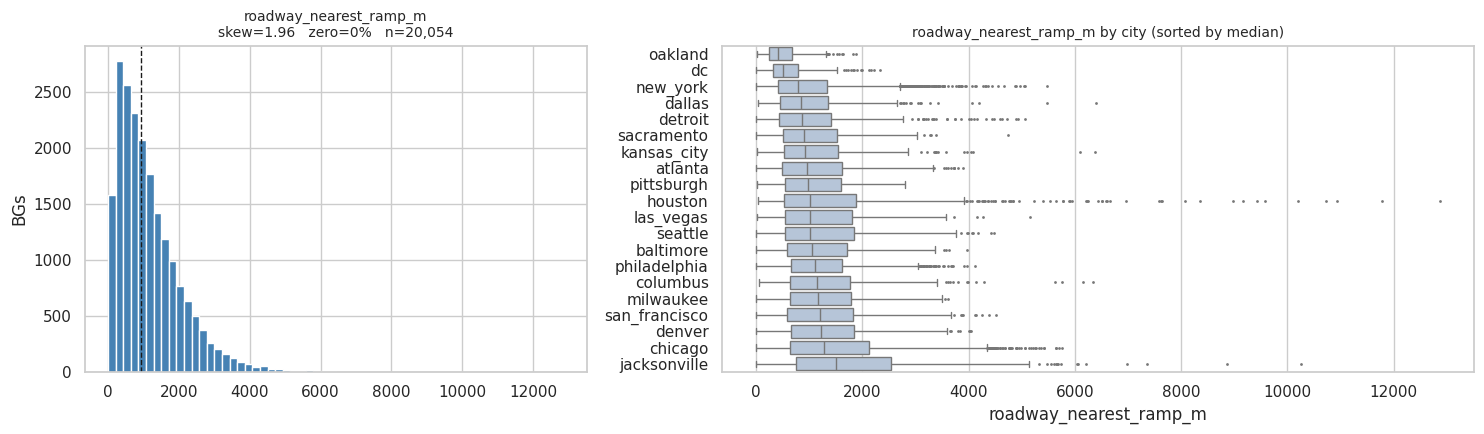

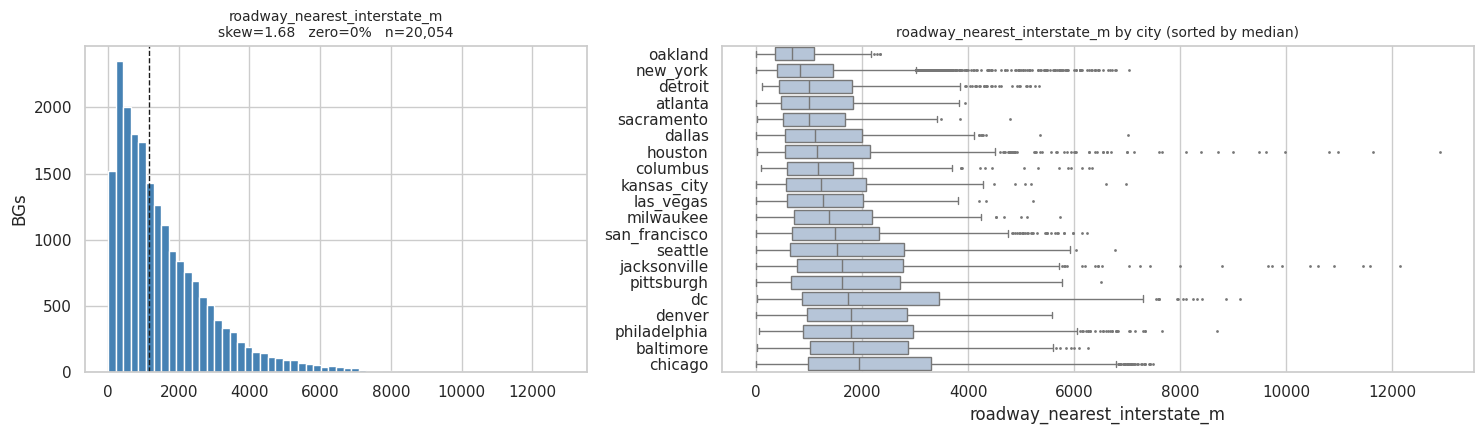

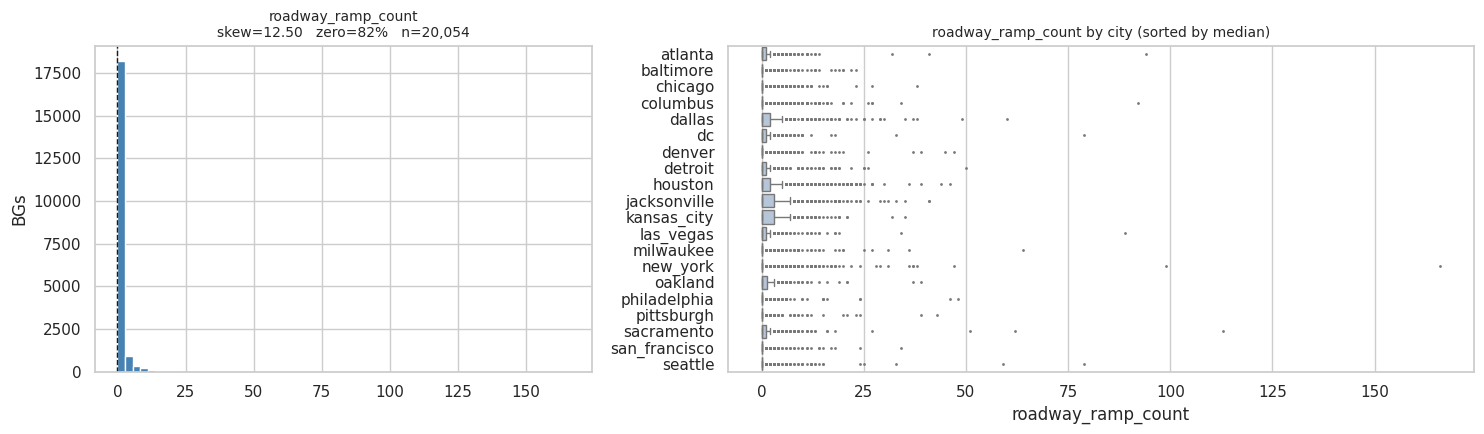

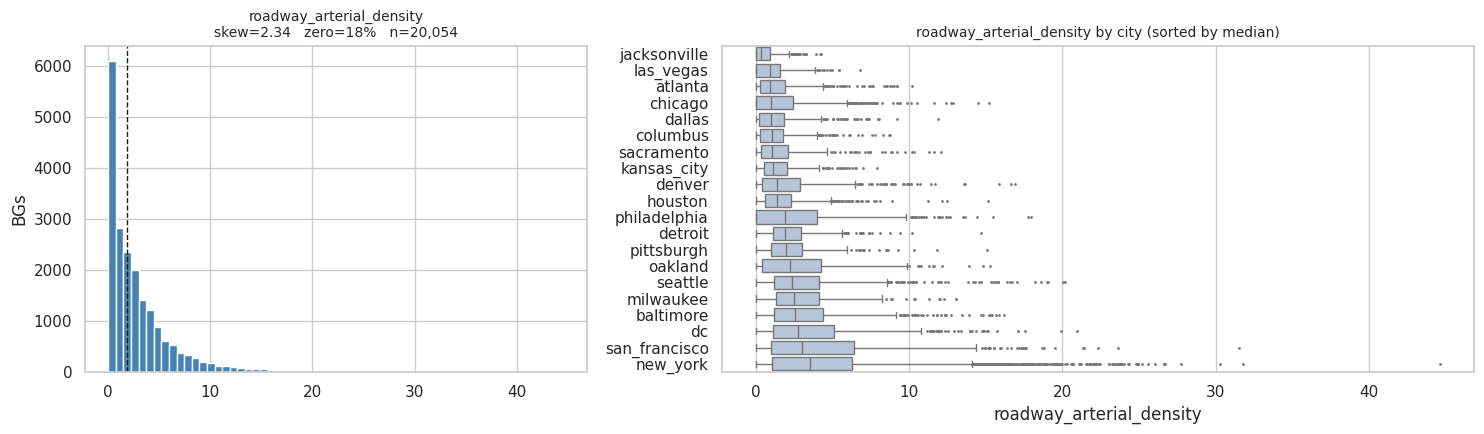

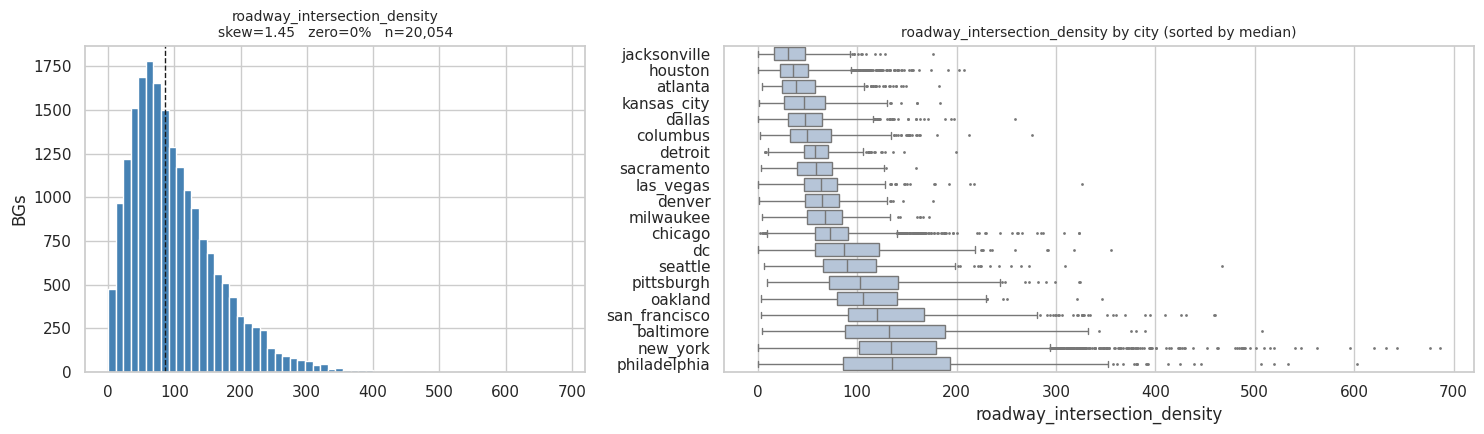

In [70]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'lap_pct'
#plot_dist(v,transform=None)

for v in FAMILIES[fam]:
    plot_dist(v,transform=None) # e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

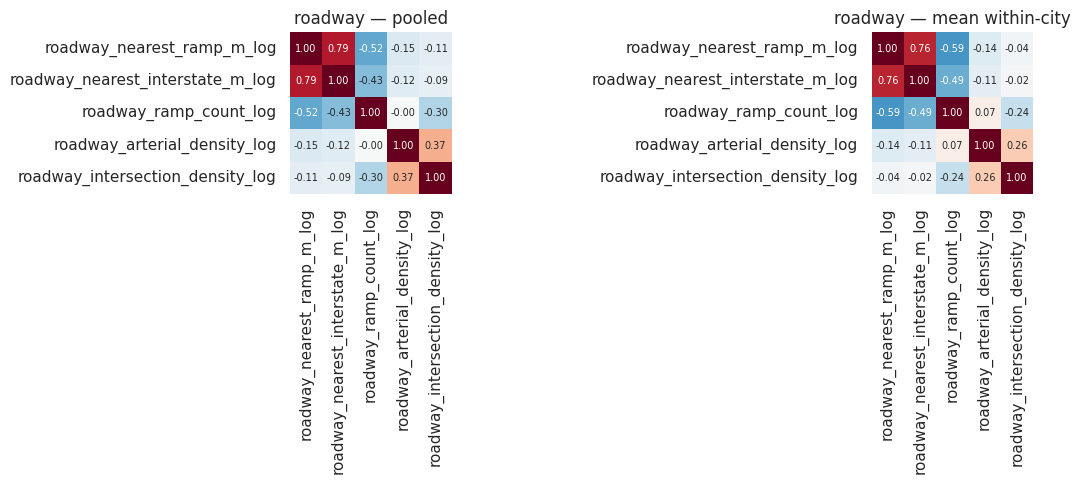

,a,b,within_rho,pooled_rho
0,roadway_nearest_ramp_m_log,roadway_nearest_interstate_m_log,0.76,0.79
1,roadway_nearest_ramp_m_log,roadway_ramp_count_log,-0.59,-0.52
2,roadway_nearest_interstate_m_log,roadway_ramp_count_log,-0.49,-0.43
4,roadway_arterial_density_log,roadway_intersection_density_log,0.26,0.37
3,roadway_ramp_count_log,roadway_intersection_density_log,-0.24,-0.30


In [71]:
 # Q3 — predictor–predictor correlation
corr_heatmaps(cols, fam)
display(top_pairs(cols, thresh=0.2))

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


total                                \
                                 pooled within_med sign_agree between   
roadway_arterial_density_log       0.19       0.18        1.0    0.28   
roadway_nearest_interstate_m_log  -0.22      -0.21        0.9   -0.25   
roadway_nearest_ramp_m_log        -0.14      -0.17        0.8   -0.03   
roadway_ramp_count_log             0.14       0.12        1.0     NaN   
roadway_intersection_density_log   0.07       0.12        0.9    0.08   

                                          property                        \
                                 n_cities   pooled within_med sign_agree   
roadway_arterial_density_log           10     0.08       0.28       1.00   
roadway_nearest_interstate_m_log       10    -0.06      -0.24       0.95   
roadway_nearest_ramp_m_log             10    -0.11      -0.22       0.85   
roadway_ramp_count_log                 10     0.20       0.15       1.00   
roadway_intersection_density_log       10    -0.13       0.11       0.85   

                                                            all  
                                 between n_cities between_share  
roadway_arterial_density_log        0.23       20          0.15  
roadway_nearest_interstate_m_log   -0.02       20          0.09  
roadway_nearest_ramp_m_log         -0.05       20          0.06  
roadway_ramp_count_log               NaN       20          0.07  
roadway_intersection_density_log    0.09       20          0.42

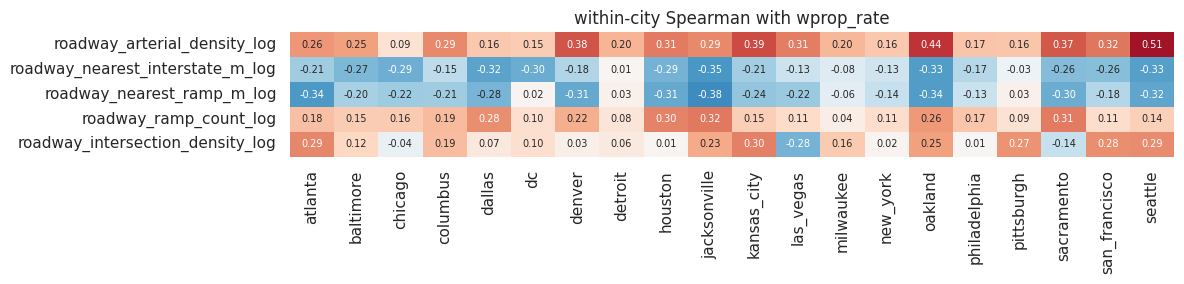

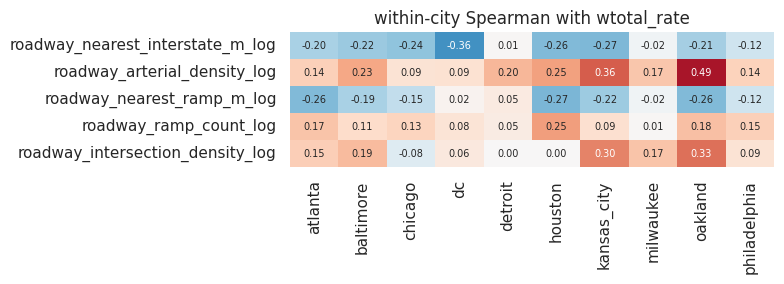

In [72]:
# Q4 — correlation with crime, pooled / within / between cities
display(target_corr_table(cols))
city_corr_heatmap(cols, "property")
city_corr_heatmap(cols, "total")

**Key Observations:**
1. Remove ramp count
2. Nearest interstate and nearest ramp are correlated - potentially keep only one but we can postpone that decision for a LightGBM run

**Transit Family**

In [12]:
fam = "transit"            # demographic | property | transit | imagery | roadway
cols = model_cols(fam)

# Q1 + Q2 — missingness and skew numbers
display(skew_table(fam))

,pct_missing_raw,pct_zero,min,median,max,model_form,skew_raw,skew_model,skew_log1p,skew_sqrt,skew_yeojohnson,best,flag
variable,,,,,,,,,,,,,
transit_stop_count,0.0,16.91,0.00,3.00,108.00,transit_stop_count_log,3.77,0.03,0.03,0.44,0.00,yeojohnson,
transit_stop_density,0.0,16.91,0.00,13.76,348.96,transit_stop_density_log,2.99,-0.55,-0.55,0.52,-0.07,yeojohnson,
transit_nearest_stop_m,0.0,0.00,0.43,179.00,14737.60,transit_nearest_stop_m_log,9.11,0.29,0.29,3.82,-0.04,yeojohnson,
transit_service_intensity,0.0,16.91,0.00,211.50,16620.00,transit_service_intensity_logc,8.74,-0.26,-1.18,1.06,-0.15,yeojohnson,
transit_overnight_stop_count,0.0,27.35,0.00,2.00,108.00,transit_overnight_stop_count_log,4.50,0.25,0.25,0.51,0.04,yeojohnson,
transit_overnight_stop_share,0.0,27.35,0.00,1.00,1.00,transit_overnight_stop_share,-0.57,-0.57,-0.66,-0.80,-0.45,yeojohnson,
transit_risky_stop_count,0.0,41.76,0.00,1.00,60.00,transit_risky_stop_count_log,4.86,0.59,0.59,0.60,0.16,yeojohnson,zero-inflated: consider has_X flag + log1p
transit_risky_stop_share,0.0,41.76,0.00,0.25,1.00,transit_risky_stop_share,0.63,0.63,0.43,0.10,0.20,sqrt,zero-inflated: consider has_X flag + log1p
transit_risky_allnight_count,0.0,49.37,0.00,1.00,55.00,transit_risky_allnight_count_log,4.75,0.79,0.79,0.76,0.27,yeojohnson,zero-inflated: consider has_X flag + log1p


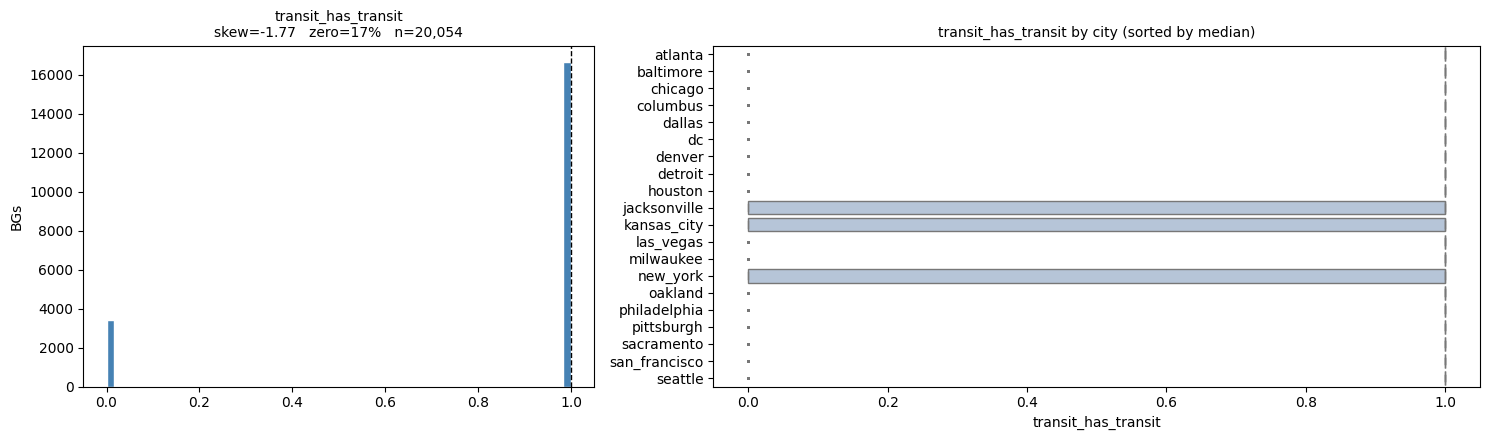

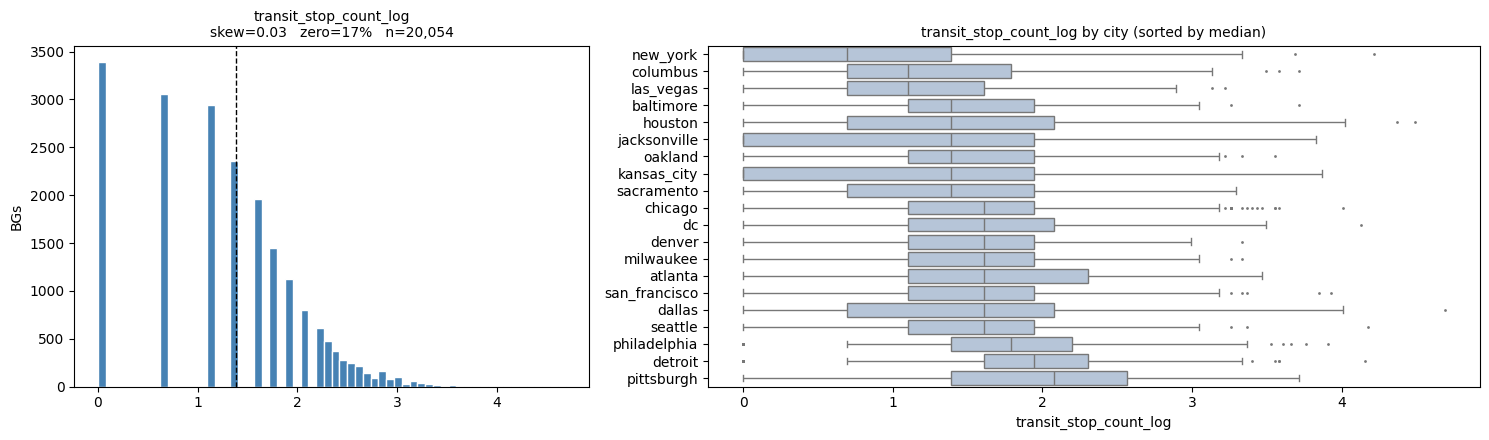

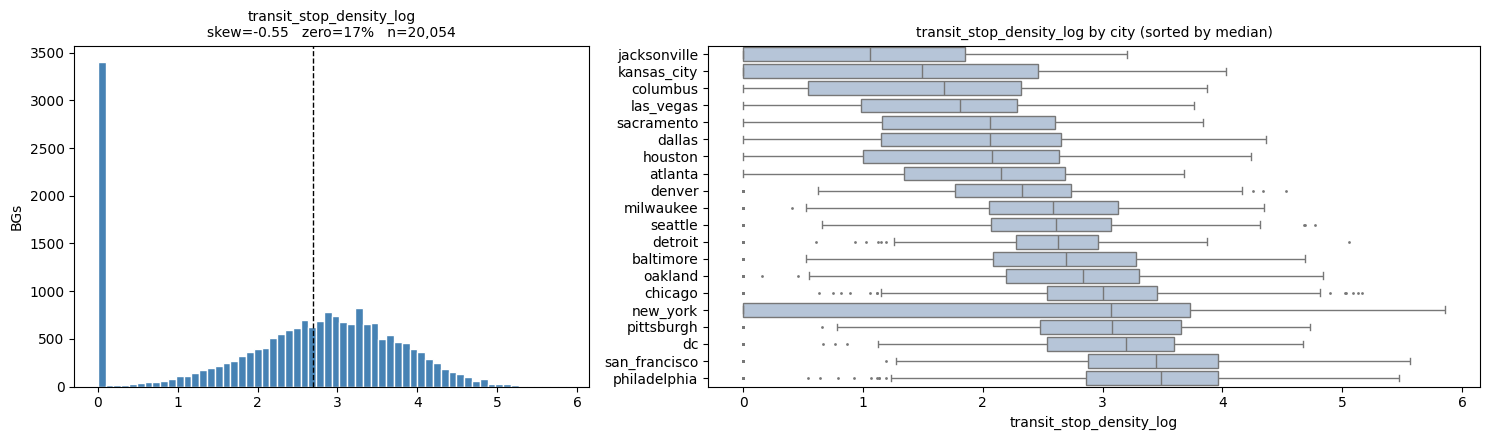

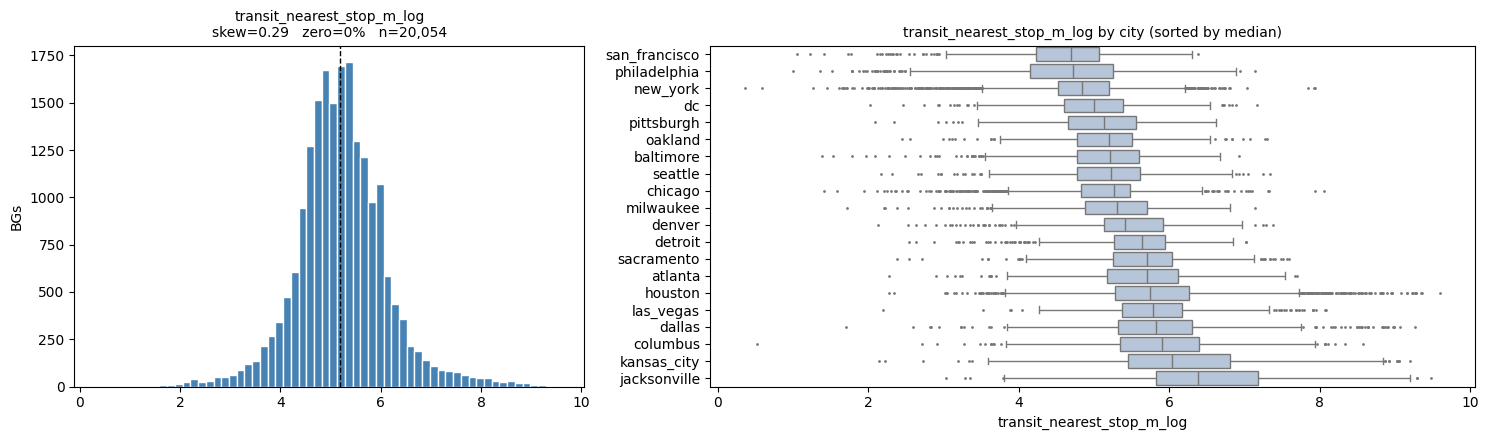

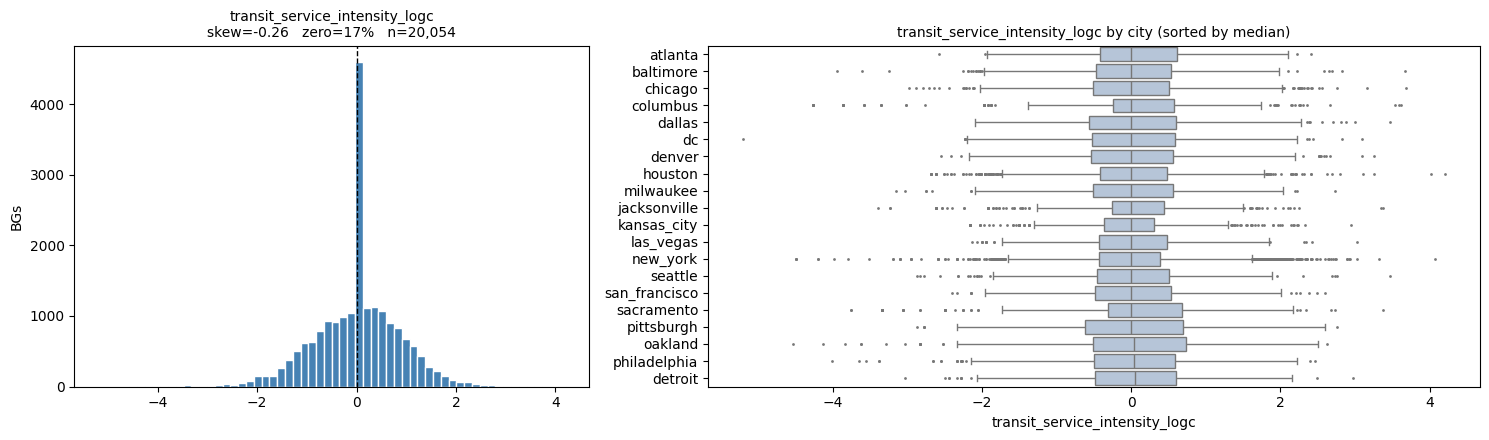

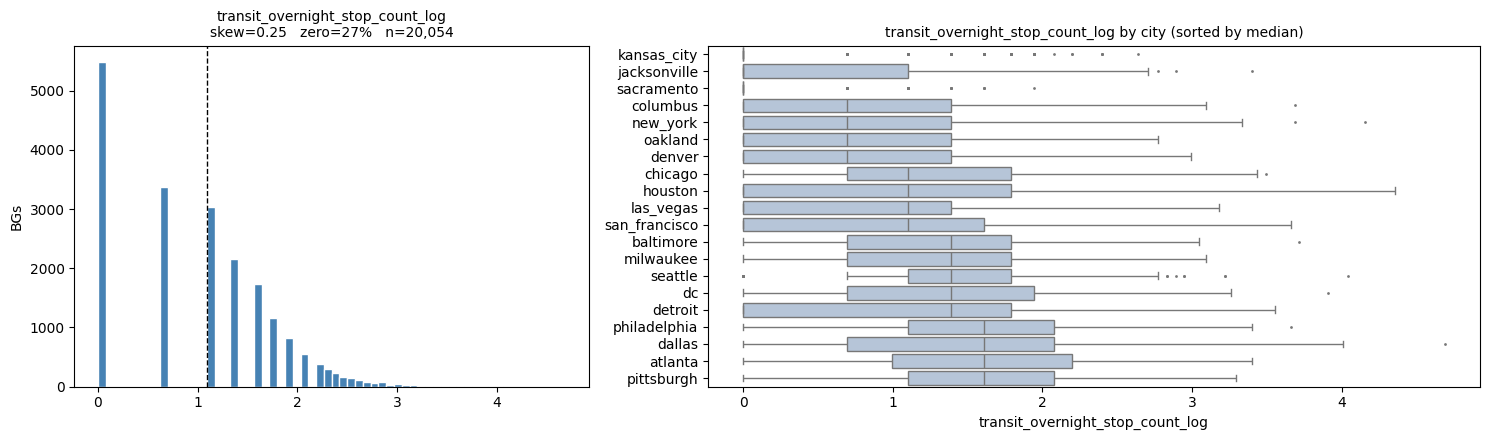

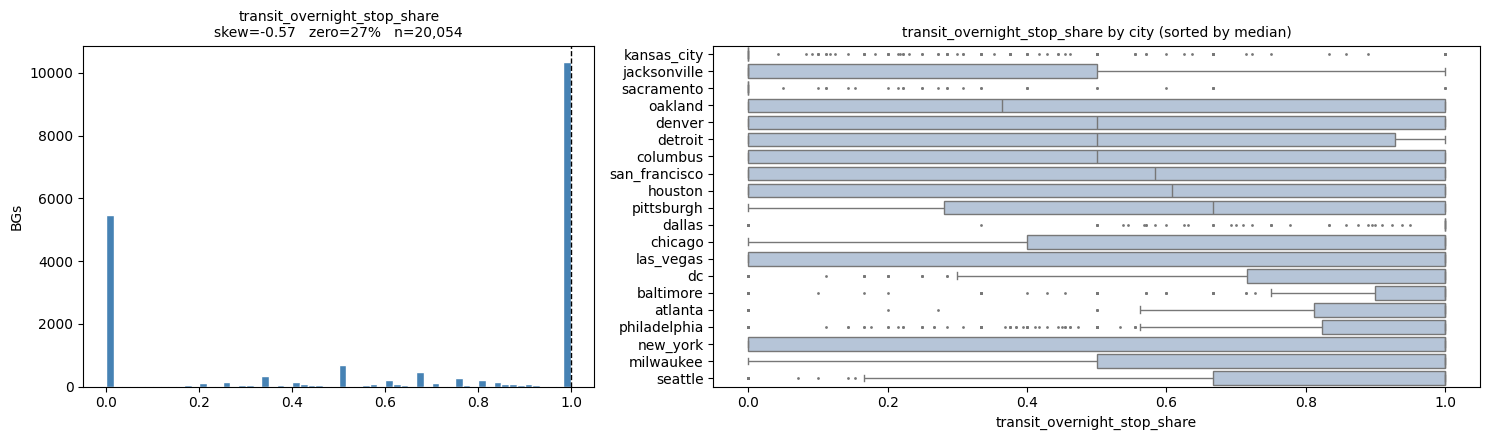

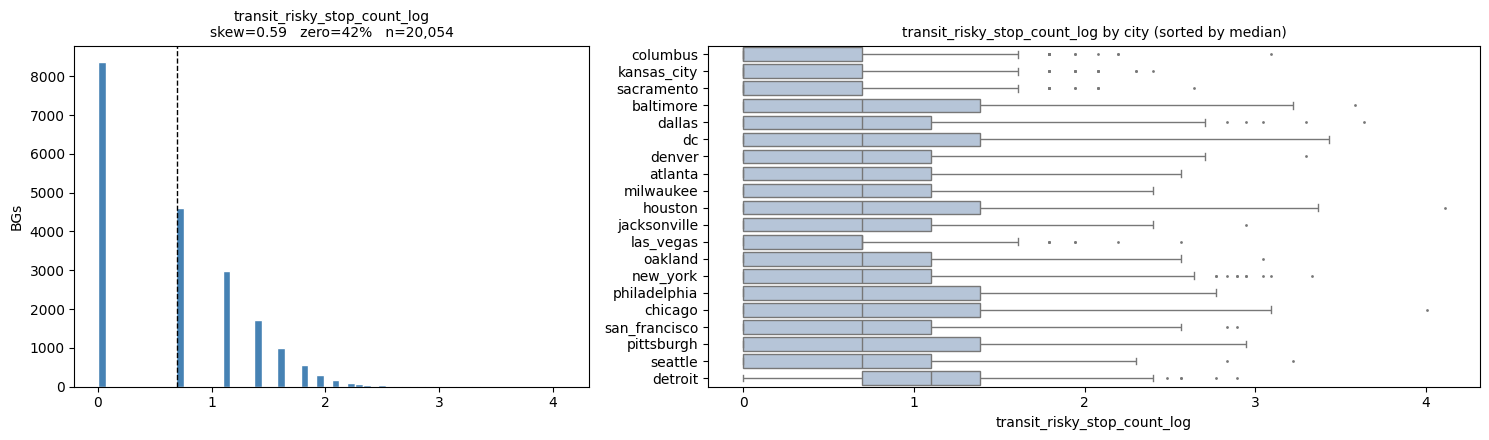

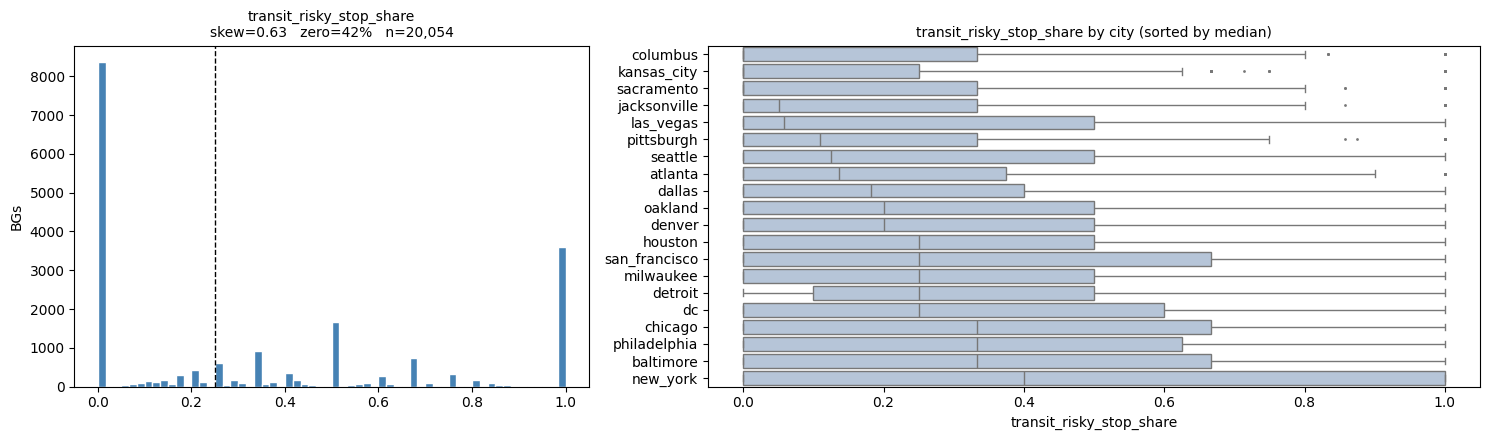

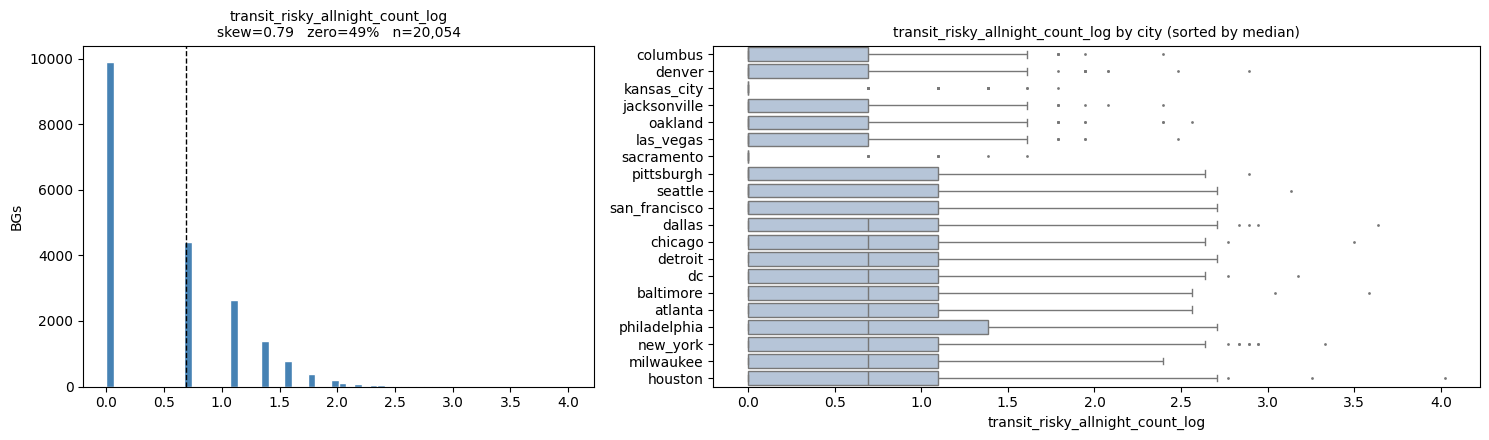

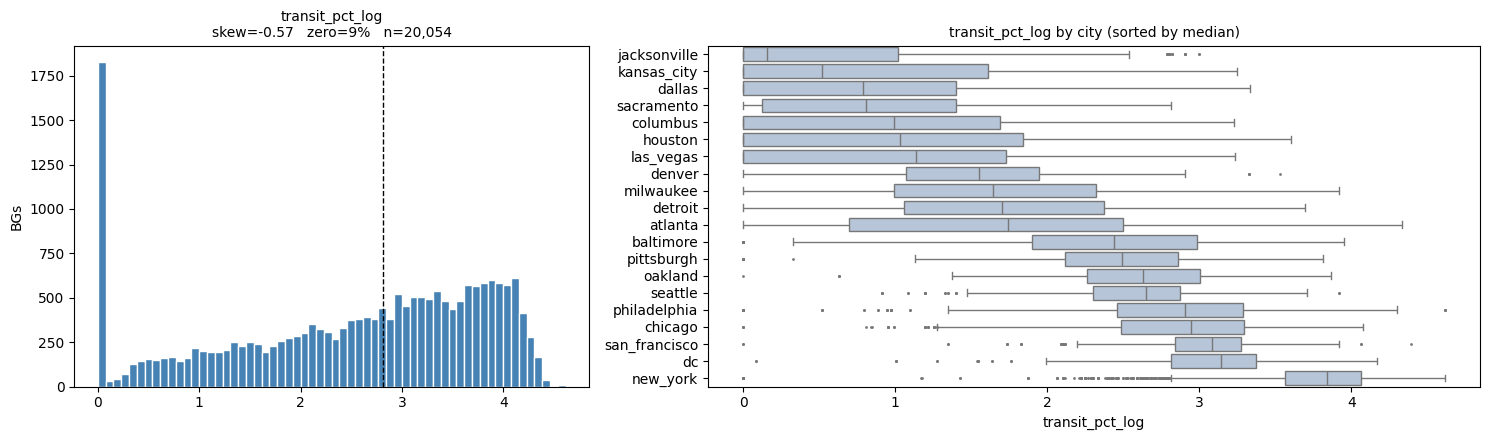

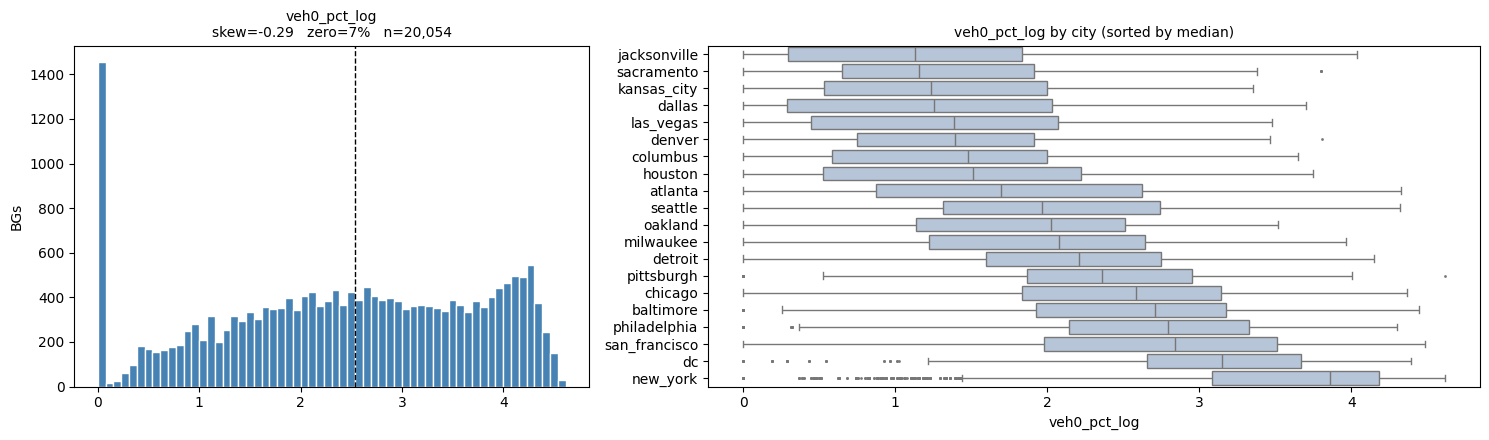

In [13]:
# Q2 — distributions, one variable at a time (try transform= to compare)
#v = 'lap_pct'
#plot_dist(v,transform=None)

for col in cols:
    plot_dist(col,transform=None) # e.g. plot_dist("vacant_pct", transform="log1p", clip_q=0.99)

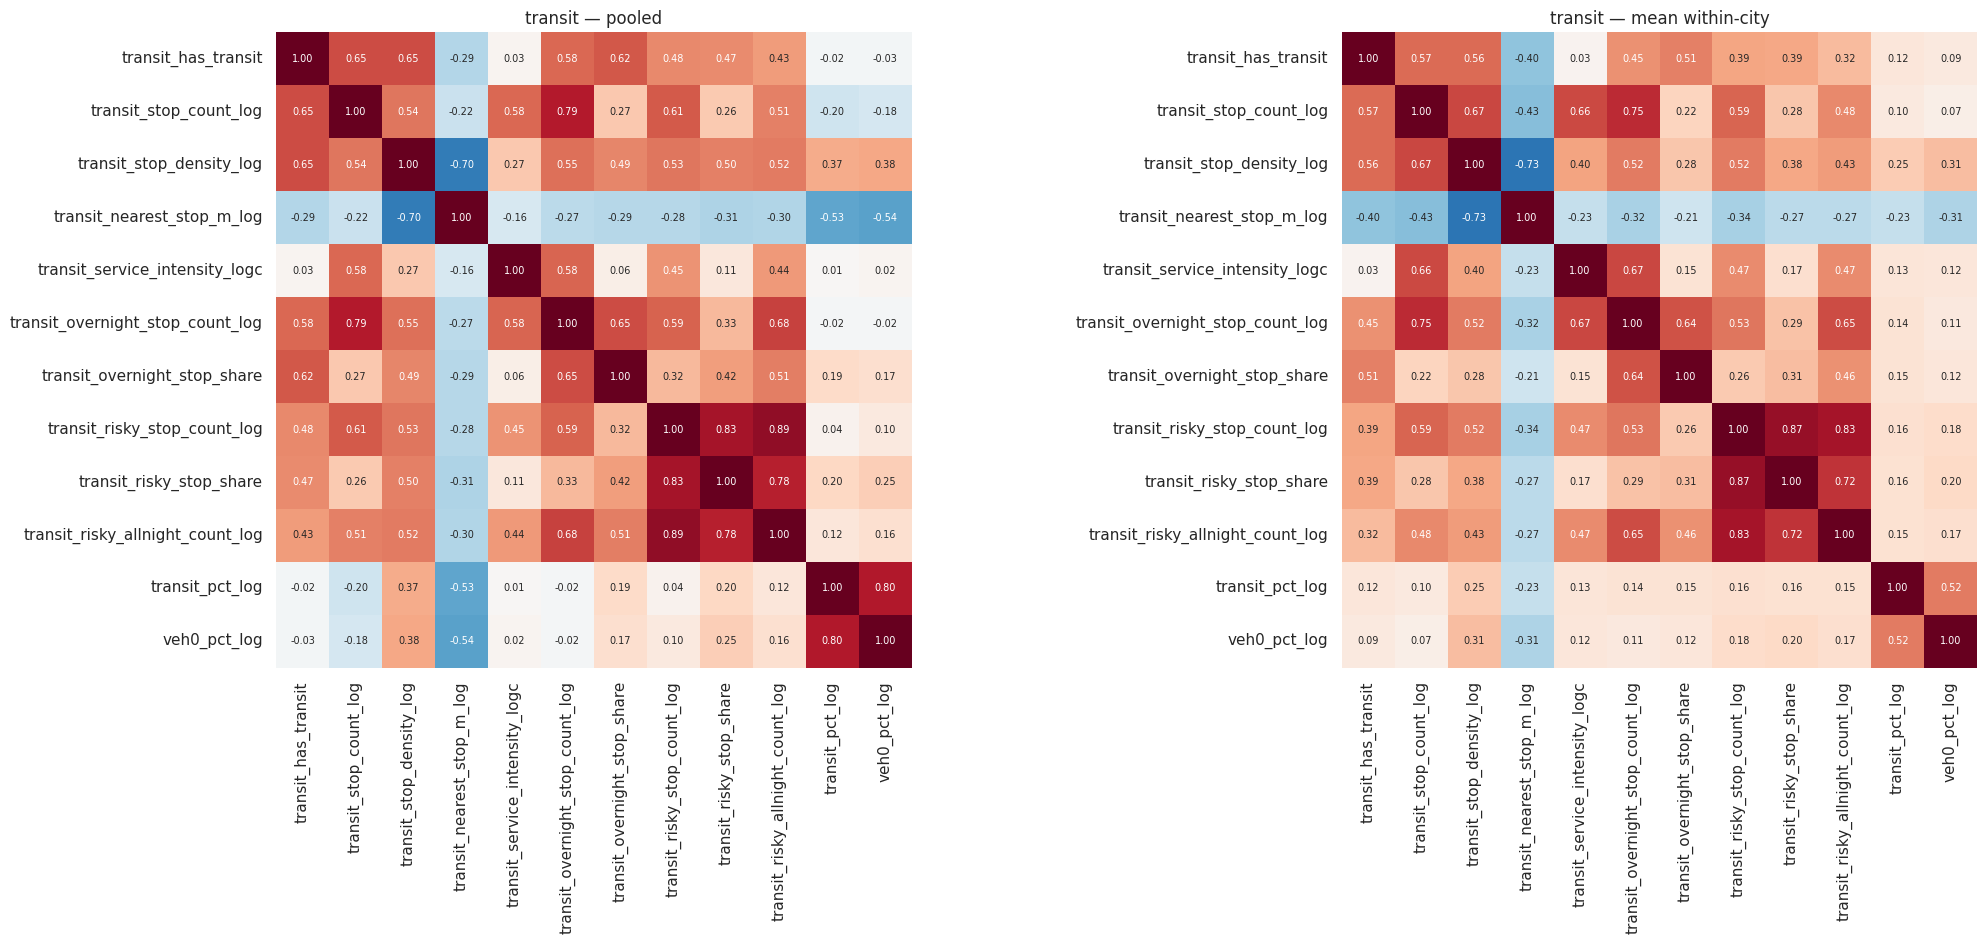

,a,b,within_rho,pooled_rho
14,transit_risky_stop_count_log,transit_risky_stop_share,0.87,0.83
15,transit_risky_stop_count_log,transit_risky_allnight_count_log,0.83,0.89
5,transit_stop_count_log,transit_overnight_stop_count_log,0.75,0.79
7,transit_stop_density_log,transit_nearest_stop_m_log,-0.73,-0.70
16,transit_risky_stop_share,transit_risky_allnight_count_log,0.72,0.78
3,transit_stop_count_log,transit_stop_density_log,0.67,0.54
10,transit_service_intensity_logc,transit_overnight_stop_count_log,0.67,0.58
4,transit_stop_count_log,transit_service_intensity_logc,0.66,0.58
13,transit_overnight_stop_count_log,transit_risky_allnight_count_log,0.65,0.68
11,transit_overnight_stop_count_log,transit_overnight_stop_share,0.64,0.65


In [77]:
 # Q3 — predictor–predictor correlation
corr_heatmaps(cols, fam)
display(top_pairs(cols, thresh=0.5))

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


total                                \
                                 pooled within_med sign_agree between   
transit_risky_stop_count_log       0.32       0.34        1.0    0.23   
veh0_pct_log                       0.25       0.33        1.0   -0.16   
transit_risky_allnight_count_log   0.28       0.30        1.0   -0.17   
transit_nearest_stop_m_log        -0.18      -0.23        1.0    0.20   
transit_risky_stop_share           0.20       0.25        1.0   -0.01   
transit_overnight_stop_count_log   0.31       0.34        1.0   -0.06   
transit_service_intensity_logc     0.31       0.32        1.0    0.40   
transit_stop_count_log             0.34       0.30        1.0   -0.02   
transit_pct_log                    0.14       0.29        1.0   -0.54   
transit_stop_density_log           0.20       0.28        1.0   -0.31   
transit_has_transit                0.23       0.15        1.0     NaN   
transit_overnight_stop_share       0.12       0.14        1.0   -0.38   

                                          property                        \
                                 n_cities   pooled within_med sign_agree   
transit_risky_stop_count_log           10     0.31       0.37        1.0   
veh0_pct_log                           10    -0.11       0.32        1.0   
transit_risky_allnight_count_log       10     0.25       0.32        1.0   
transit_nearest_stop_m_log             10    -0.03      -0.31        1.0   
transit_risky_stop_share               10     0.14       0.31        1.0   
transit_overnight_stop_count_log       10     0.33       0.30        1.0   
transit_service_intensity_logc         10     0.25       0.30        1.0   
transit_stop_count_log                 10     0.42       0.28        1.0   
transit_pct_log                        10    -0.23       0.26        1.0   
transit_stop_density_log               10     0.13       0.26        1.0   
transit_has_transit                    10     0.26       0.15        1.0   
transit_overnight_stop_share           10     0.08       0.12        1.0   

                                                            all  
                                 between n_cities between_share  
transit_risky_stop_count_log        0.27       20          0.04  
veh0_pct_log                        0.06       20          0.45  
transit_risky_allnight_count_log    0.09       20          0.06  
transit_nearest_stop_m_log         -0.07       20          0.29  
transit_risky_stop_share            0.18       20          0.06  
transit_overnight_stop_count_log    0.20       20          0.16  
transit_service_intensity_logc      0.37       20          0.00  
transit_stop_count_log              0.32       20          0.15  
transit_pct_log                     0.04       20          0.72  
transit_stop_density_log            0.11       20          0.15  
transit_has_transit                  NaN       20          0.06  
transit_overnight_stop_share       -0.06       20          0.15

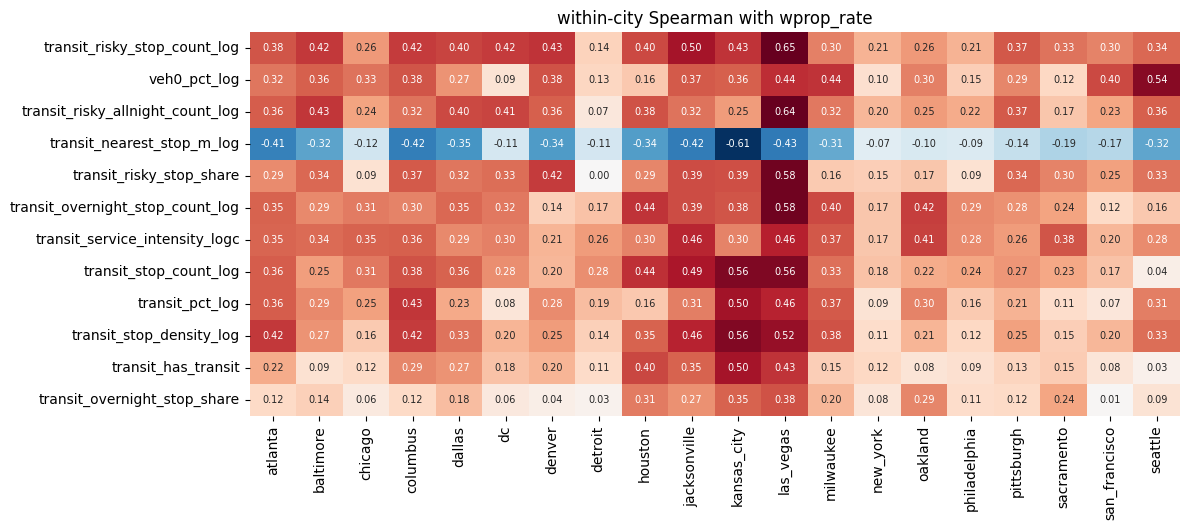

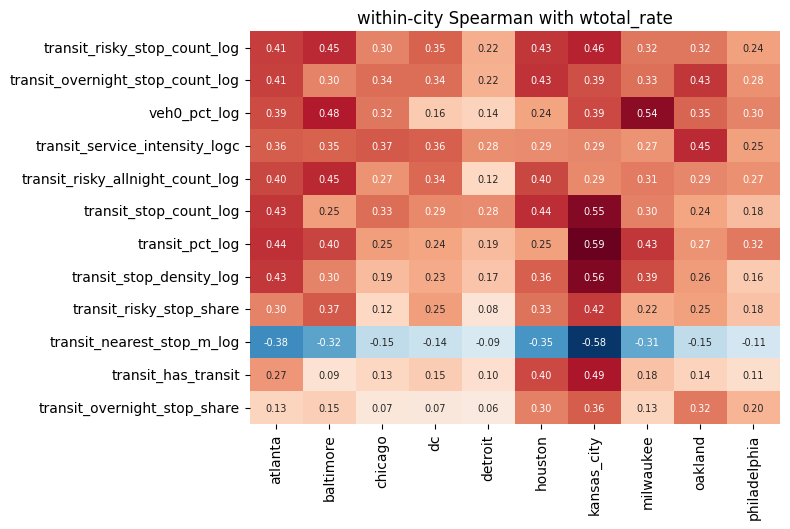

In [14]:
# Q4 — correlation with crime, pooled / within / between cities
display(target_corr_table(cols))
city_corr_heatmap(cols, "property")
city_corr_heatmap(cols, "total")

**Key Observations:**
1. Features to keep:
    * has_transit
    * transit_risky_stop_count_log
    * transit_service_intensity_logc
    * ~~transit_overnight_stop_count_log~~
    * *veh0_pct_log* is tricky because will most likely be an income proxy. TO-DO: Add bus_pct and re-run 

2. Scraping transit: we should do it, even if this is done in batches. Similar to Experian data, this is the kind of stuff that will be our moat, not just for the crime product.  

**All Observations:**
1. Concentration: 20% of BGs hold 40–60% of crime and 50% hold about 80%. The job is separating the top 20% from the next 30%. Detroit is diffuse, so it's hard.
2. Transforms: don't matter much for LightGBM, and neither does correlation. Flag predictors that are redundant and add no unique signal.
3. Demographic:  det_pct  is the redundant one.
4. Property:
    * Drop liens (suspect calculation or source).
    * Keep the foreclosure spatial lag.
    * Vacancy is strong on its own; the lag is optional but more defensible for compliance.
    * TO-DO: The transaction chain -> houses put up, interest through Home Shopper data and actually sold 
    * Convenience stores give property-crime lift; the hypothesis needs more thought.
5. Imagery: missing material is useless. Parking lots are worth trying.
6. Roadway: drop ramp count. Interstate and ramp distance overlap; let LightGBM decide.

**Interaction Terms**

Boosted Trees should take care of interactions but no harm in checking

In [15]:
# ---------- interactions: build a × b, then reuse the Q2–Q4 helpers above ----------
def add_interaction(a, b, how="product", name=None):
    """Add an `a × b` column to `pool` and return its name.
    how='product': a * b on the columns as given (pass model forms, e.g. *_log).
    how='rank'   : product of within-city percentile ranks (0–1). Scale-free and city-relative:
                   high only where BOTH are high for that city. Ties at the minimum (e.g. no
                   risky stop) rank near 0, so they stay near 0 in the product.
    how='z'      : product of within-city z-scores. Positive = both on the same side of the
                   city mean; the parents' main effects are centred out."""
    x, y, g = pool[a].astype(float), pool[b].astype(float), pool["city"]
    if how == "rank":
        x = x.groupby(g).rank(pct=True, method="min")
        y = y.groupby(g).rank(pct=True, method="min")
    elif how == "z":
        z = lambda s: (s - s.groupby(g).transform("mean")) / s.groupby(g).transform("std")
        x, y = z(x), z(y)
    elif how != "product":
        raise ValueError(f"unknown how {how!r}")
    name = name or f"{a}_x_{b}" + ("" if how == "product" else f"_{how}")
    pool[name] = x * y
    return name

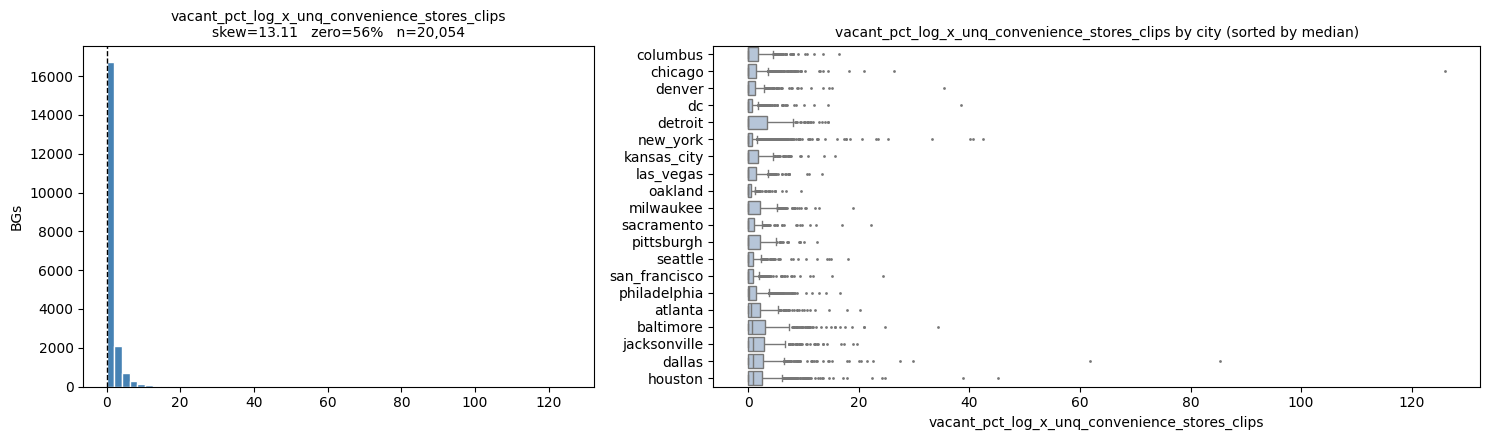

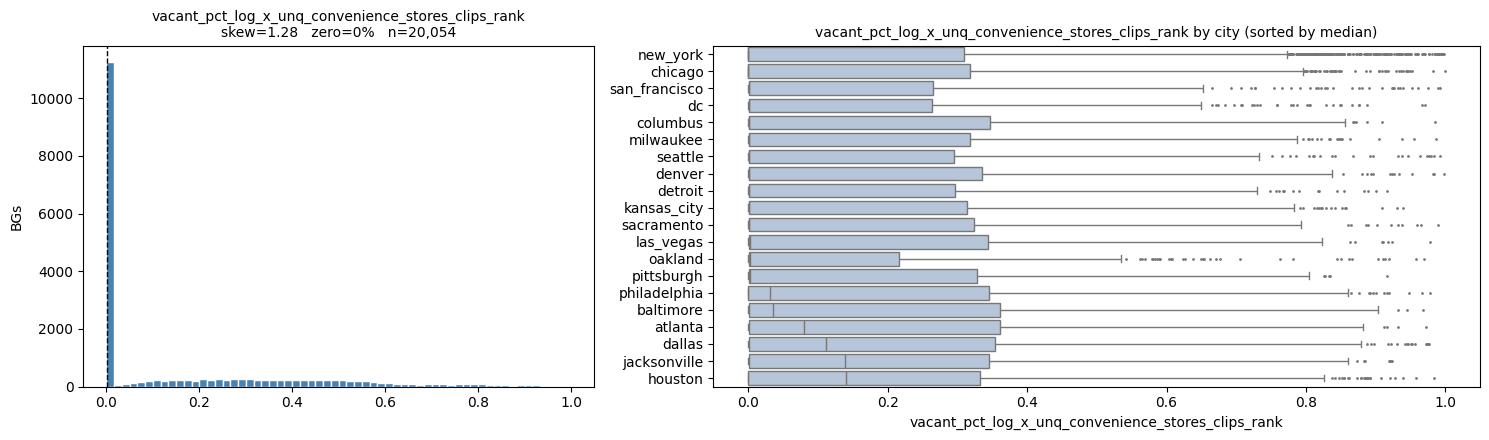

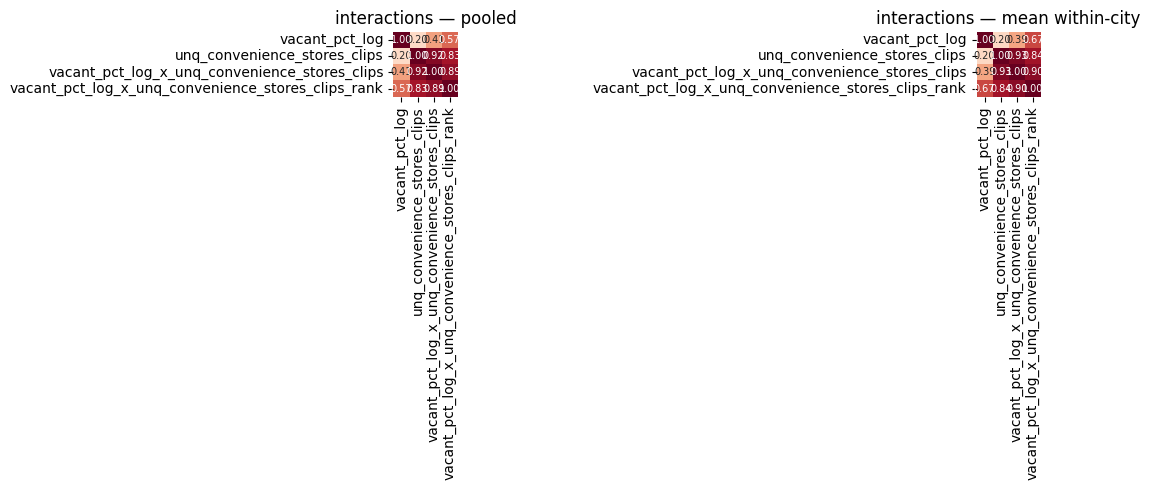

total             \
                                                   pooled within_med   
vacant_pct_log_x_unq_convenience_stores_clips_rank   0.40       0.42   
vacant_pct_log                                       0.50       0.48   
vacant_pct_log_x_unq_convenience_stores_clips        0.33       0.33   
unq_convenience_stores_clips                         0.24       0.26   

                                                                       \
                                                   sign_agree between   
vacant_pct_log_x_unq_convenience_stores_clips_rank        1.0    0.13   
vacant_pct_log                                            1.0    0.70   
vacant_pct_log_x_unq_convenience_stores_clips             1.0   -0.05   
unq_convenience_stores_clips                              1.0   -0.07   

                                                            property  \
                                                   n_cities   pooled   
vacant_pct_log_x_unq_convenience_stores_clips_rank       10     0.37   
vacant_pct_log                                           10     0.46   
vacant_pct_log_x_unq_convenience_stores_clips            10     0.31   
unq_convenience_stores_clips                             10     0.22   

                                                                          \
                                                   within_med sign_agree   
vacant_pct_log_x_unq_convenience_stores_clips_rank       0.38        1.0   
vacant_pct_log                                           0.35        1.0   
vacant_pct_log_x_unq_convenience_stores_clips            0.34        1.0   
unq_convenience_stores_clips                             0.28        1.0   

                                                                     \
                                                   between n_cities   
vacant_pct_log_x_unq_convenience_stores_clips_rank    0.10       20   
vacant_pct_log                                        0.16       20   
vacant_pct_log_x_unq_convenience_stores_clips        -0.01       20   
unq_convenience_stores_clips                          0.02       20   

                                                             all  
                                                   between_share  
vacant_pct_log_x_unq_convenience_stores_clips_rank          0.01  
vacant_pct_log                                              0.31  
vacant_pct_log_x_unq_convenience_stores_clips               0.05  
unq_convenience_stores_clips                                0.05

In [18]:
INTERACTIONS = [("vacant_pct_log", "unq_convenience_stores_clips")]   # (a, b) pairs; add more here
HOWS = ["product", "rank"]                                            # compare forms side by side

ix_cols = [add_interaction(a, b, how) for a, b in INTERACTIONS for how in HOWS]
parents = list(dict.fromkeys(c for pair in INTERACTIONS for c in pair))
cols = parents + ix_cols
for c in ix_cols:
    plot_dist(c)
corr_heatmaps(cols, "interactions")
#display(top_pairs(cols, thresh=0.5))
display(target_corr_table(cols))
#city_corr_heatmap(cols, "property")
#city_corr_heatmap(cols, "total")